The following notebook assumes that the `rec_hits` csv file exists and was generated by `root2csv` with the `-l` and `-g` flags.

In [105]:
import pandas as pd
import numpy  as np
import math

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_style("darkgrid")

In [107]:
## connessione al google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [108]:
# ~~+ Global 2D coordinates. +~~~
bg  = "#DA9EAA"
pal = sns.dark_palette("#B92544", as_cmap = True)

# Plot entire dRICH cell map in the EIC global x, y coordinates.
def global2d_plotcells(df):
    sns.scatterplot(
        x = df["gx"], y = df["gy"],
        s = .4, edgecolor = None, color = bg#, hue = df["pdu"]#, legend = "full"
    )

# Plot hits from event `ei` in the EIC global x, y coordinates.
def global2d_plothits(df, ei,c="blue"):
    df = df[df["event"] == ei]
    sns.scatterplot(
        x = df["gx"], y = df["gy"],
        s = 10, color=c# hue = df["pindex"],
    )

def global2d_plothits_tag(df, tf, ei):
    df = df[df["event"] == ei]
    tf = tf[tf["event"] == ei]
    x_a=[]
    y_a=[]
    hue_a=[]
    print("START")
    for idx, row in df.iterrows():
        x_a.append(row["gx"])
        y_a.append(row["gy"])
        if(row["pindex"]==0):
            #print("NOISE")
            hue_a.append(0)
        else:
            for idx_t, row_t in tf.iterrows():
                if(row["pindex"]==row_t["pindex"]):
                    #print("MATCH!")
                    hue_a.append(row_t["pdg"])
                    #print(row_t["pdg"])
                    break

    print(np.asarray(x_a).shape)
    print(np.asarray(y_a).shape)
    print(np.asarray(hue_a).shape)

    sns.scatterplot(
        x = x_a, y = y_a,
        s = 10, hue = hue_a, palette =  sns.color_palette()
    )

def global2d_plothits_timing(df, ei):
    df = df[df["event"] == ei]
    hue_t=[]
    max_time = max(df["time"])
    print(max_time)
    for idx, row in df.iterrows():
        hue_t.append(round(row["time"]))

    sns.scatterplot(
        x = df["gx"], y = df["gy"],
        s = 10, hue = hue_t, palette =  sns.color_palette()
    )

In [109]:
# ~~+ Local 2D coordinates. +~~~
# Build cell matrix for sector `sec` in its local coordinate system.
def local_buildmatrix(df, sec):
    df = df[df["sector"] == sec]

    # Get size and generate matrix.
    #matrix_dims = (df["lx"].max()+1, df["ly"].max()+1)
    rot_x_max = df["lx"].max()*math.cos(math.radians(-30)) - df["ly"].max()*math.sin(math.radians(-30))
    rot_y_max = df["lx"].max()*math.sin(math.radians(-30)) + df["ly"].max()*math.cos(math.radians(-30))

   # print(rot_x_max)
   # print(rot_y_max)
    matrix_dims = (df["lx"].max()+1, df["ly"].max()+1)

    cell_matrix = np.zeros((matrix_dims[0], matrix_dims[1]))
    #print("Matrix dims: [%d,%d]" % (matrix_dims[0], matrix_dims[1]))

    # Iterate cells.
    for idx, row in df.iterrows():
        x, y = int(row["lx"]), int(row["ly"])

        rot_x = x*math.cos(0) - y*math.sin(0)
        rot_y = x*math.sin(0) + y*math.cos(0)
        #x, y = round(row["gx"])+xmin, round(row["gy"])+ymin

        # Check if two cells have the same position.
        # if (cell_matrix[x][y] > .1):
        #     print("Error: Duplicate input in cell [%d,%d]" % (x, y))

        # Fill matrix with the base value 100. Deposited charge is usually over
        #     200, so this allows for easy differentiation.
        cell_matrix[round(rot_x)][round(rot_y)] = 100

    return cell_matrix

# Add deposited charge in event `ei` to cell matrix for sector `sec` in its lo-
#     cal coordinate system.
def local_addcharge(matrix, df, ei, sec):
    df = df[(df["event"] == ei) & (df["sector"] == sec)]

    for idx, row in df.iterrows():
        matrix[int(row["lx"])][int(row["ly"])] += row["charge"]*2*5
        #matrix[round(row["gx"])][round(row["gy"])] += row["charge"]


def global_buildmatrix(df,localmatrix):

    global_matrix = np.zeros((355, 355))
    for sec in range(0,6):
        print(sec)
        file = df[df["sector"] == sec]

        #gx_min = -177
        #gy_min = -177
        #gx_max = +177
        #gy_max = +177
        # Get size and generate matrix.
        #matrix_dims = (int((-1*gx_min)+gx_max)+1, int((-1*gy_min)+gy_max)+1)

        #global_matrix = np.zeros((matrix_dims[0], matrix_dims[1]))
    #print("Matrix dims: [%d,%d]" % (matrix_dims[0], matrix_dims[1]))

    # Iterate cells.
        for idx, row in file.iterrows():
            x, y = int(row["gx"]), int(row["gy"])
            lx, ly =  int(row["lx"]), int(row["ly"])
           # print(lx)
           # print(ly)

        # Check if two cells have the same position.
        # if (cell_matrix[x][y] > .1):
        #     print("Error: Duplicate input in cell [%d,%d]" % (x, y))

        # Fill matrix with the base value 100. Deposited charge is usually over
        #     200, so this allows for easy differentiation.
            global_matrix[(x+177)][(y+177)] = localmatrix[sec][lx][ly]

    return global_matrix


In [110]:
def matrix_segmentation(matrix,xmax,ymax):
    sipm_count = [0, 0, 0, 0, 0]

    for x in range(0,55):
        for y in range(31,65):
            if(y>=-0.891*x+81 and matrix[y][x]!=0):
                matrix[y][x]+= 200
                sipm_count[0]+=1

    for x in range(55,xmax):
        for y in range(31,65):
            if(y>=+0.891*x-17 and matrix[y][x]!=0):
                matrix[y][x]+= 200
                sipm_count[0]+=1

    for x in range(0,55):
        for y in range(31,ymax):
            if(y<-0.891*x+81 and matrix[y][x]!=0):
                matrix[y][x]+= 300
                sipm_count[1]+=1
    for x in range(55,xmax):
        for y in range(31,ymax):
            if(y<+0.891*x-17 and matrix[y][x]!=0):
                matrix[y][x]+= 400
                sipm_count[2]+=1

    for x in range(0,55):
        for y in range(0,31):
            if(matrix[y][x]!=0):
                matrix[y][x]+= 500
                sipm_count[3]+=1

    for x in range(55,xmax):
        for y in range(0,31):
            if(matrix[y][x]!=0):
                matrix[y][x]+= 600
                sipm_count[4]+=1
    print(sipm_count)

    sipm_proof = 6720 -(sipm_count[0]+sipm_count[1]+sipm_count[2]+sipm_count[3])
    print("List of sipm_count: \n")
    print(sipm_proof)

def matrix_segmentation_local(matrix,x_center,y_center,c1,c2):
    sipm_count = [0, 0, 0, 0, 0]
    lx_sector_lists = [[],[],[],[],[]]
    ly_sector_lists = [[],[],[],[],[]]


    m1 = (c1-y_center)/x_center
    m2 = (c2-y_center)/x_center


    for x in range(0,413):
        for y in range(y_center,371):
            if( y>=-m1*x+c1 and matrix[y][x]!=0):
                matrix[y][x]+= 200
                sipm_count[0]+=1
                lx_sector_lists[0].append(x)
                ly_sector_lists[0].append(y)

    for x in range(0,413):
        for y in range(y_center,371):
            if( y<=-m1*x+c1 and matrix[y][x]!=0):
                matrix[y][x]+= 400
                sipm_count[1]+=1
                lx_sector_lists[1].append(x)
                ly_sector_lists[1].append(y)

    for x in range(0,x_center):
        for y in range(0,189):
            if(matrix[y][x]!=0):
                matrix[y][x]+= 600
                sipm_count[2]+=1
                lx_sector_lists[2].append(x)
                ly_sector_lists[2].append(y)

    for x in range(x_center,455):
        for y in range(0,y_center):
            if(y<=-m2*x+c2 and matrix[y][x]!=0):
                matrix[y][x]+= 800
                sipm_count[3]+=1
                lx_sector_lists[3].append(x)
                ly_sector_lists[3].append(y)

    for x in range(x_center,455):
        for y in range(0,y_center):
            if(y>=-m2*x+c2 and matrix[y][x]!=0):
                matrix[y][x]+= 1000
                sipm_count[4]+=1
                lx_sector_lists[4].append(x)
                ly_sector_lists[4].append(y)

    #print("List of sipm_count: \n")
    #print(sipm_count)

    sipm_proof = 6720 -(sipm_count[0]+sipm_count[1]+sipm_count[2]+sipm_count[3])

    return lx_sector_lists,ly_sector_lists


def grid_def(lx_sector_lists, ly_sector_lists, size):
    grid = 0
    x_step, y_step = 0, 0
    #size = 64


    grid_matrix = np.zeros((5,size, size))
    grid_list_subsector = []
    lx_max = []
    ly_max = []
    lx_min = []
    ly_min = []

    for n in range(0,5):
        grid_list_subsector.append([])
        lx_max.append(max(lx_sector_lists[n]))
        ly_max.append(max(ly_sector_lists[n]))
        lx_min.append(min(lx_sector_lists[n]))
        ly_min.append(min(ly_sector_lists[n]))
        for gd_x in range(0,size):
            grid_list_subsector[n].append([])
            for gd_y in range(0,size):
                grid_list_subsector[n][gd_x].append([])


    for n in range(0,5):
        for i in range(0,len(lx_sector_lists[n])):
            x = lx_sector_lists[n][i]-lx_min[n]
            y = ly_sector_lists[n][i]-ly_min[n]
            if([x,y]==[x_step,y_step]):
                continue
            else:
                x_step=x
                y_step=y
            for gd_x in range(0,size):
                for gd_y in range(0,size):
                    if(x<((gd_x+1)/size)*(lx_max[n]-lx_min[n]) and x>(gd_x/size)*(lx_max[n]-lx_min[n]) and y<((gd_y+1)/size)*(ly_max[n]-ly_min[n]) and y>(gd_y/size)*(ly_max[n]-ly_min[n])):
                            #matrix[y][x]+=500*(gd_x*32+gd_y*8)#(gd_x*8+gd_y+1)*100
                            grid_list_subsector[n][gd_x][gd_y].append([lx_sector_lists[n][i],ly_sector_lists[n][i]])
                            grid_matrix[n][gd_x][gd_y]+= 1



    return grid_matrix, grid_list_subsector





In [111]:
def grid_ev(lx_sector_lists, ly_sector_lists, size, df, ei,sec):
    grid = 0
    x_step, y_step = 0, 0

    grid_matrix = np.zeros((5,size, size))
    grid_lists = [[],[],[],[],[]]

    lx_max = []
    ly_max = []
    lx_min = []
    ly_min = []

    ev_x_lists = []
    ev_y_lists = []

    for n in range(0,5):
        lx_max.append(max(lx_sector_lists[n]))
        ly_max.append(max(ly_sector_lists[n]))
        lx_min.append(min(lx_sector_lists[n]))
        ly_min.append(min(ly_sector_lists[n]))

    #for n in range(0,6):
    df = df[(df["event"] == ei) & (df["sector"] == sec)]
    for idx, row in df.iterrows():
            ev_x_lists.append(int(row["lx"]))
            ev_y_lists.append(int(row["ly"]))



    for n in range(0,5):
        for i in range(0,len(lx_sector_lists[n])):
            x0 = lx_sector_lists[n][i]
            y0 = ly_sector_lists[n][i]
            x = x0 - lx_min[n]
            y = y0 - ly_min[n]
            if([x,y]==[x_step,y_step]):
                continue
            else:
                x_step=x
                y_step=y
            if(ev_x_lists.count(x0)>0 and ev_y_lists.count(y0)>0):
                #print(x,y)
                for gd_x in range(0,size):
                    for gd_y in range(0,size):
                        if(x<((gd_x+1)/size)*(lx_max[n]-lx_min[n]) and x>(gd_x/size)*(lx_max[n]-lx_min[n]) and y<((gd_y+1)/size)*(ly_max[n]-ly_min[n]) and y>(gd_y/size)*(ly_max[n]-ly_min[n])):
                            grid_lists[n].append([x0,y0])
                            #matrix[y][x]+=500*(gd_x*32+gd_y*8)#(gd_x*8+gd_y+1)*100
                            grid_matrix[n][gd_x][gd_y]+= 1



    return grid_matrix,grid_lists

In [112]:
!ls

all_dams_geometry.png  drive  report_plots_histo  sample_data


In [113]:
# Get data.

c_x, c_y = 175, 189      # mêmes constantes que dataset_ALCOR_fromcampaign_timingaware.ipynb, cellule 2
c1, c2 = 680, 320
SIZE = 8

df_cellmap      = pd.read_csv("/content/drive/MyDrive/project_files/cellmap.csv",  sep = ',')
#df_rec_last    = pd.read_csv("Bkg_1SignalPer2usframe_2601/rec_hits_0002.csv", sep = ',')
df_rec_last     = pd.read_csv("/content/drive/MyDrive/project_files/Bkg_new/rec_hits_0002.csv", sep = ',')
df_sim_last     = pd.read_csv("/content/drive/MyDrive/project_files/Bkg_new/sim_parts_0002.csv", sep = ',')
df_noise        = pd.read_csv("/content/drive/MyDrive/project_files/Noise_files/no_time/csv_reco/noise_reco_0_150kHz_10ns.csv", sep = ',')

In [114]:
def rank_bin(values, n_bins):
    order = np.argsort(np.argsort(values))
    n = len(values)
    return np.minimum((order * n_bins) // n, n_bins - 1)

DAM_SHAPES = {0: (21, 3), 1: (21, 3), 2: (21, 3), 3: (17, 4), 4: (17, 4)}  # (n_rows, n_cols) par DAM

def build_dam_grid_lookup_v7(df_cellmap, dam_shapes):
    lookup = {}
    shapes_used = {}
    for sec in range(6):
        sec_df = df_cellmap[df_cellmap["sector"] == sec].copy()
        sec_df["subsec"] = sec_df["pdu"] // 42
        sec_df["subpdu"] = sec_df["pdu"] % 42
        for n in range(5):
            n_rows, n_cols = dam_shapes[n]   # n_rows = le long du GRAND axe, n_cols = le PETIT axe
            sub = sec_df[sec_df["subsec"] == n]
            centroids = sub.groupby("subpdu")[["lx", "ly"]].mean().reset_index()
            subpdu = centroids["subpdu"].astype(int).values
            pts = centroids[["lx", "ly"]].values

            # PCA : trouve l'orientation réelle du nuage de points
            pts_c = pts - pts.mean(axis=0)
            cov = np.cov(pts_c.T)
            eigvals, eigvecs = np.linalg.eigh(cov)          # ordre croissant des valeurs propres
            order = np.argsort(eigvals)[::-1]                # on veut décroissant
            eigvecs = eigvecs[:, order]                       # colonne 0 = grand axe, colonne 1 = petit axe

            proj = pts_c @ eigvecs   # proj[:,0] = position le long du grand axe, proj[:,1] = le long du petit axe

            gx = rank_bin(proj[:, 0], n_rows)   # binning le long du grand axe (incliné)
            gy = rank_bin(proj[:, 1], n_cols)   # binning le long du petit axe

            cell_map = {}
            for i, ch in enumerate(subpdu):
                cell_map.setdefault((int(gx[i]), int(gy[i])), []).append(ch)
            lookup[(sec, n)] = cell_map
            shapes_used[(sec, n)] = (n_rows, n_cols)
    return lookup, shapes_used

lookup, shapes_used = build_dam_grid_lookup_v7(df_cellmap, DAM_SHAPES)

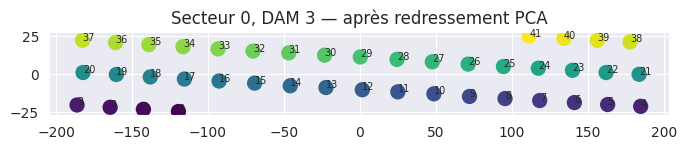

Ratio largeur/longueur (eigvals[1]/eigvals[0]) = 0.015


In [115]:
sec, n = 0, 3
sec_df = df_cellmap[df_cellmap["sector"] == sec].copy()
sec_df["subsec"] = sec_df["pdu"] // 42
sec_df["subpdu"] = sec_df["pdu"] % 42
sub = sec_df[sec_df["subsec"] == n]
centroids = sub.groupby("subpdu")[["lx", "ly"]].mean().reset_index()
pts = centroids[["lx", "ly"]].values
pts_c = pts - pts.mean(axis=0)
cov = np.cov(pts_c.T)
eigvals, eigvecs = np.linalg.eigh(cov)
order = np.argsort(eigvals)[::-1]
eigvecs = eigvecs[:, order]
proj = pts_c @ eigvecs

plt.figure(figsize=(8, 3))
plt.scatter(proj[:, 0], proj[:, 1], c=centroids["subpdu"], cmap="viridis", s=100)
for i, row in centroids.iterrows():
    plt.annotate(str(int(row["subpdu"])), (proj[i, 0], proj[i, 1]), fontsize=7)
plt.title(f"Secteur {sec}, DAM {n} — après redressement PCA")
plt.gca().set_aspect("equal")
plt.show()
print(f"Ratio largeur/longueur (eigvals[1]/eigvals[0]) = {eigvals[order[1]]/eigvals[order[0]]:.3f}")

In [116]:
for (sec, n), cell_map in lookup.items():
    n_rows, n_cols = shapes_used[(sec, n)]
    all_ch = [ch for chans in cell_map.values() for ch in chans]
    n_collisions = sum(1 for chans in cell_map.values() if len(chans) > 1)
    n_empty = n_rows*n_cols - len(cell_map)
    status = "OK" if len(set(all_ch)) == 42 else "PROBLÈME"
    print(f"Secteur {sec}, DAM {n} ({n_rows}x{n_cols}): {len(set(all_ch))}/42 canaux, {n_collisions} collisions, {n_empty} cases vides — {status}")

Secteur 0, DAM 0 (21x3): 42/42 canaux, 1 collisions, 22 cases vides — OK
Secteur 0, DAM 1 (21x3): 42/42 canaux, 1 collisions, 22 cases vides — OK
Secteur 0, DAM 2 (21x3): 42/42 canaux, 0 collisions, 21 cases vides — OK
Secteur 0, DAM 3 (17x4): 42/42 canaux, 4 collisions, 30 cases vides — OK
Secteur 0, DAM 4 (17x4): 42/42 canaux, 2 collisions, 28 cases vides — OK
Secteur 1, DAM 0 (21x3): 42/42 canaux, 1 collisions, 22 cases vides — OK
Secteur 1, DAM 1 (21x3): 42/42 canaux, 1 collisions, 22 cases vides — OK
Secteur 1, DAM 2 (21x3): 42/42 canaux, 0 collisions, 21 cases vides — OK
Secteur 1, DAM 3 (17x4): 42/42 canaux, 4 collisions, 30 cases vides — OK
Secteur 1, DAM 4 (17x4): 42/42 canaux, 2 collisions, 28 cases vides — OK
Secteur 2, DAM 0 (21x3): 42/42 canaux, 1 collisions, 22 cases vides — OK
Secteur 2, DAM 1 (21x3): 42/42 canaux, 1 collisions, 22 cases vides — OK
Secteur 2, DAM 2 (21x3): 42/42 canaux, 0 collisions, 21 cases vides — OK
Secteur 2, DAM 3 (17x4): 42/42 canaux, 4 collisions

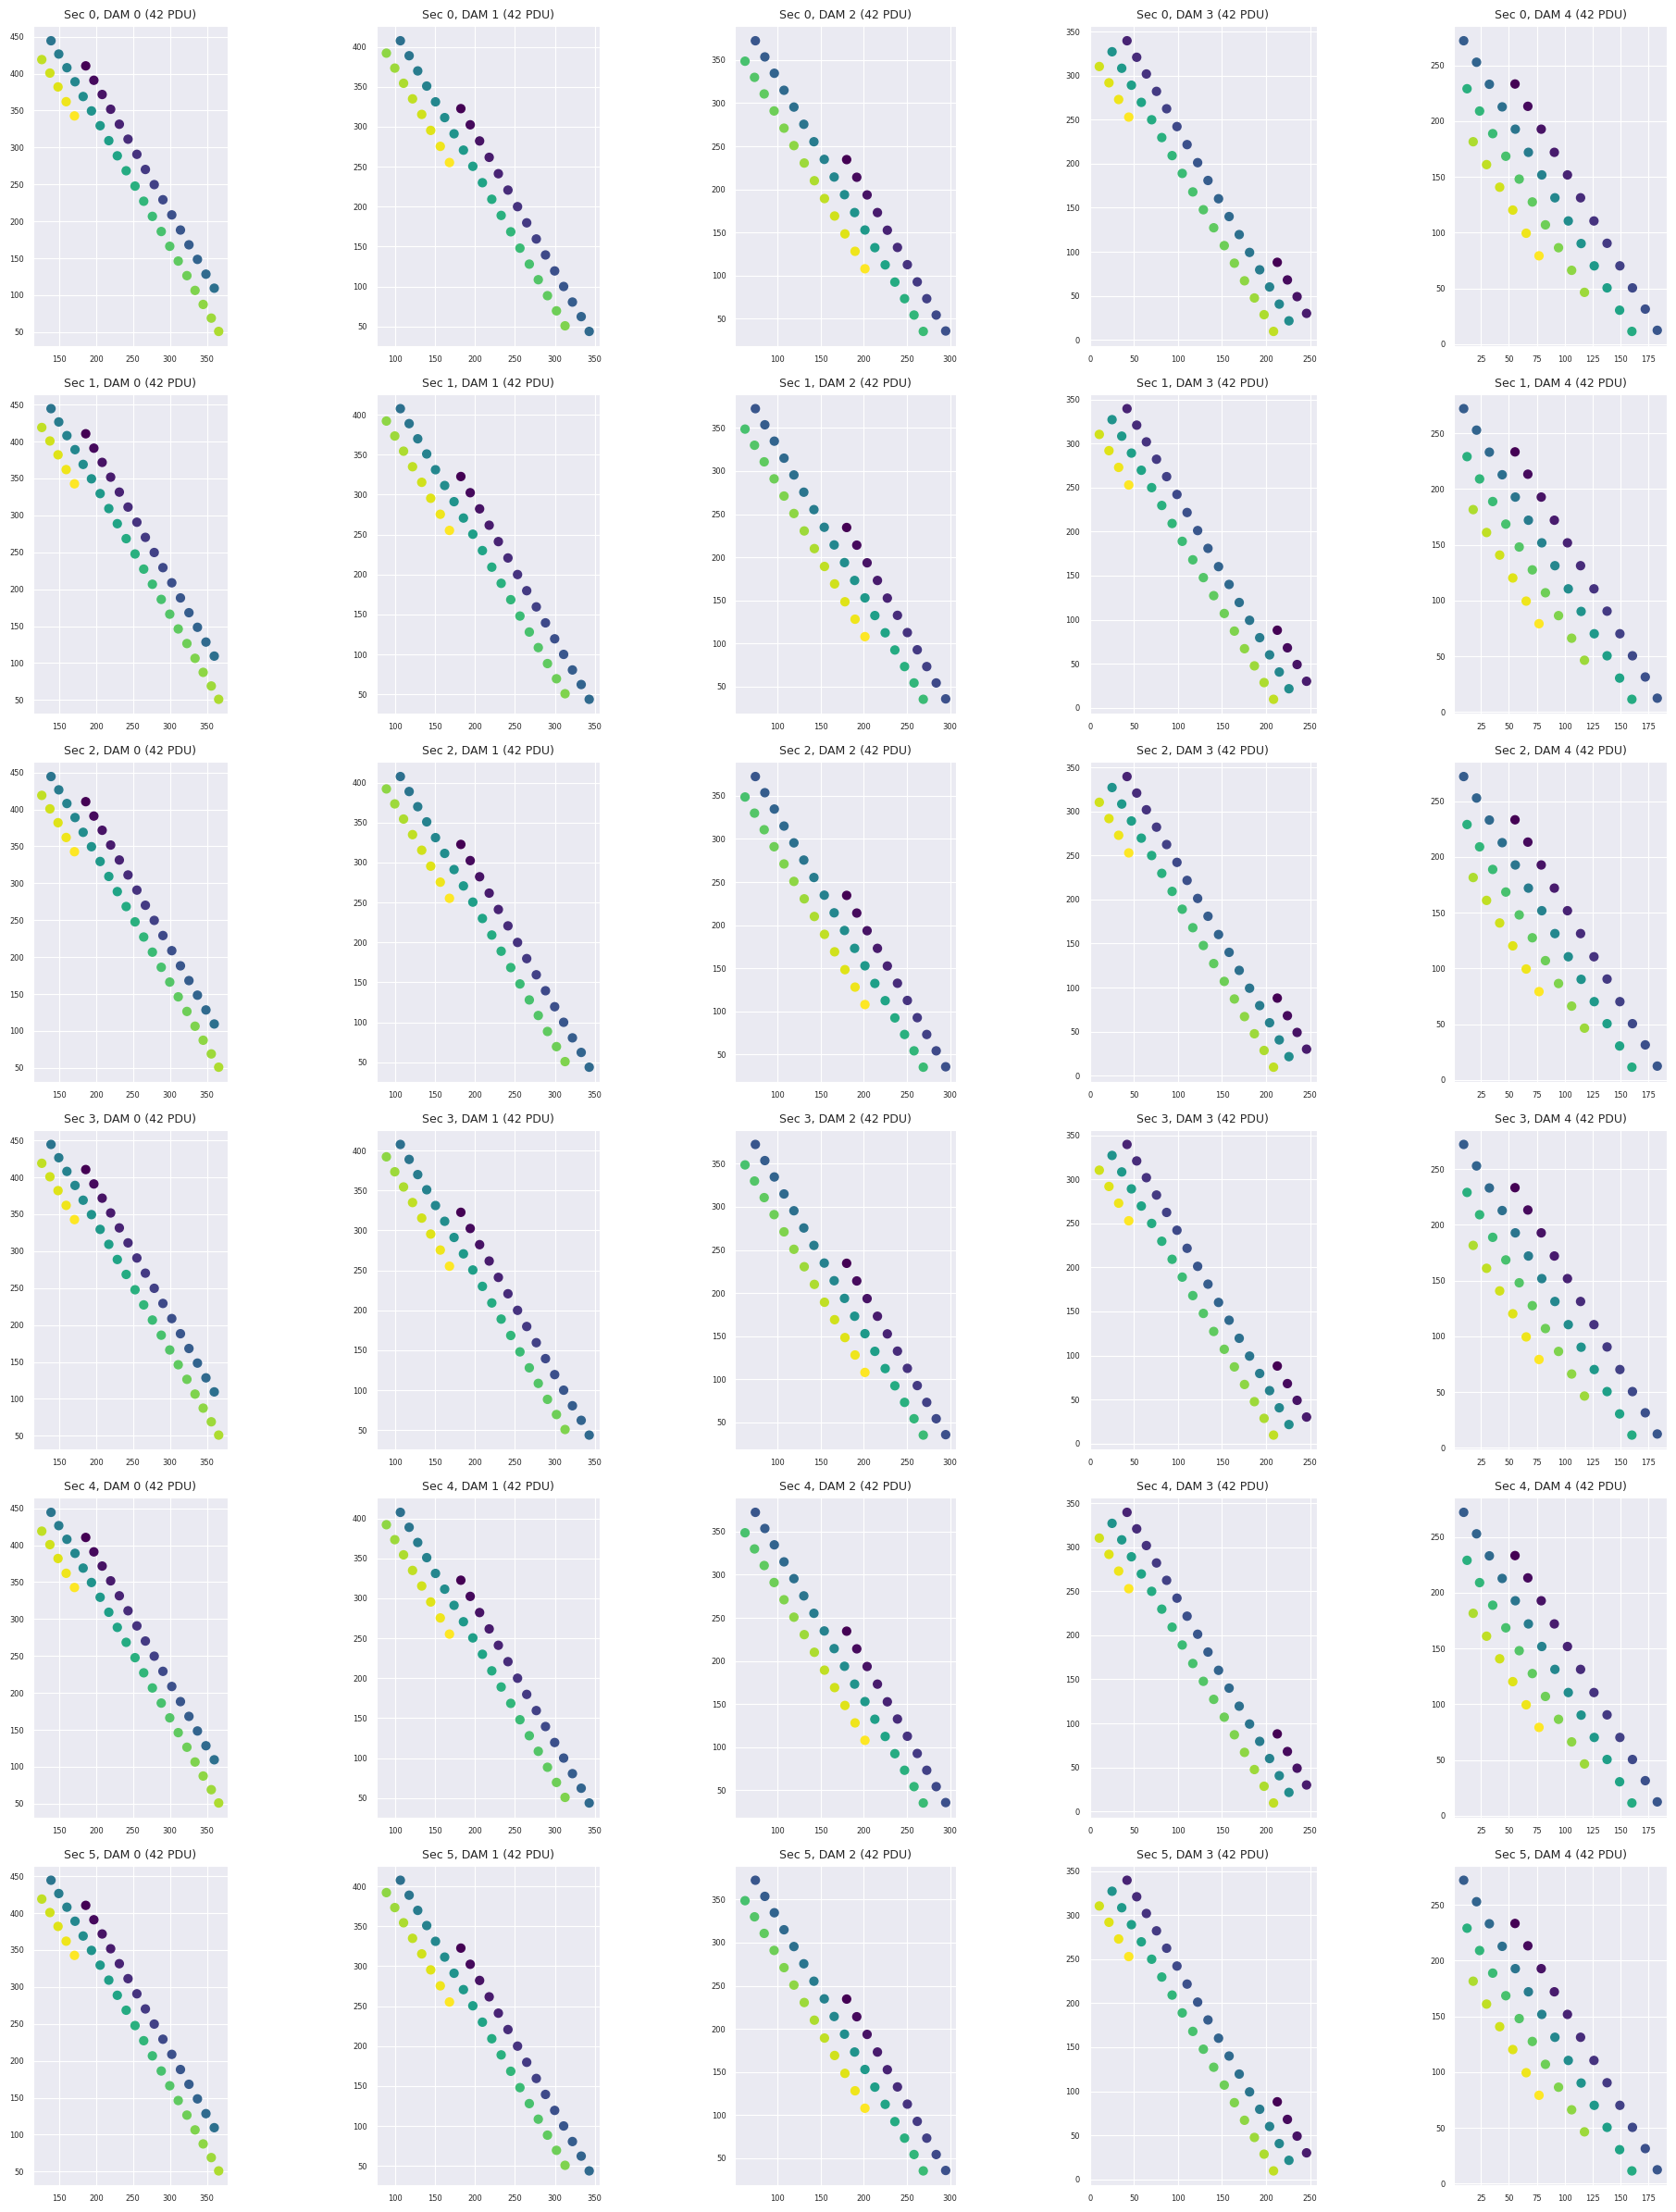

In [117]:
fig, axes = plt.subplots(6, 5, figsize=(20, 24))

for sec in range(6):
    sec_df = df_cellmap[df_cellmap["sector"] == sec].copy()
    sec_df["subsec"] = sec_df["pdu"] // 42
    sec_df["subpdu"] = sec_df["pdu"] % 42

    for n in range(5):
        ax = axes[sec, n]
        sub = sec_df[sec_df["subsec"] == n]
        centroids = sub.groupby("subpdu")[["lx", "ly"]].mean().reset_index()

        sc = ax.scatter(centroids["lx"], centroids["ly"],
                         c=centroids["subpdu"], cmap="viridis", s=40)
        ax.set_title(f"Sec {sec}, DAM {n} ({len(centroids)} PDU)", fontsize=9)
        ax.set_aspect("equal")
        ax.tick_params(labelsize=6)

plt.tight_layout()
plt.savefig("all_dams_geometry.png", dpi=150)
plt.show()

In [118]:
def shape_diagnostics(df_cellmap):
    results = []
    for sec in range(6):
        sec_df = df_cellmap[df_cellmap["sector"] == sec].copy()
        sec_df["subsec"] = sec_df["pdu"] // 42
        sec_df["subpdu"] = sec_df["pdu"] % 42
        for n in range(5):
            sub = sec_df[sec_df["subsec"] == n]
            centroids = sub.groupby("subpdu")[["lx", "ly"]].mean().values
            centroids_c = centroids - centroids.mean(axis=0)
            cov = np.cov(centroids_c.T)
            eigvals = np.sort(np.linalg.eigvalsh(cov))[::-1]  # [plus grande, plus petite]
            ratio = eigvals[1] / eigvals[0]   # proche de 0 = quasi 1D, proche de 1 = quasi carré/rond
            results.append((sec, n, ratio))
            print(f"Secteur {sec}, DAM {n}: ratio largeur/longueur = {ratio:.3f}")
    return results

_ = shape_diagnostics(df_cellmap)

Secteur 0, DAM 0: ratio largeur/longueur = 0.013
Secteur 0, DAM 1: ratio largeur/longueur = 0.012
Secteur 0, DAM 2: ratio largeur/longueur = 0.018
Secteur 0, DAM 3: ratio largeur/longueur = 0.015
Secteur 0, DAM 4: ratio largeur/longueur = 0.059
Secteur 1, DAM 0: ratio largeur/longueur = 0.013
Secteur 1, DAM 1: ratio largeur/longueur = 0.012
Secteur 1, DAM 2: ratio largeur/longueur = 0.018
Secteur 1, DAM 3: ratio largeur/longueur = 0.015
Secteur 1, DAM 4: ratio largeur/longueur = 0.059
Secteur 2, DAM 0: ratio largeur/longueur = 0.013
Secteur 2, DAM 1: ratio largeur/longueur = 0.012
Secteur 2, DAM 2: ratio largeur/longueur = 0.018
Secteur 2, DAM 3: ratio largeur/longueur = 0.015
Secteur 2, DAM 4: ratio largeur/longueur = 0.059
Secteur 3, DAM 0: ratio largeur/longueur = 0.013
Secteur 3, DAM 1: ratio largeur/longueur = 0.012
Secteur 3, DAM 2: ratio largeur/longueur = 0.018
Secteur 3, DAM 3: ratio largeur/longueur = 0.015
Secteur 3, DAM 4: ratio largeur/longueur = 0.059
Secteur 4, DAM 0: ra

In [119]:
def scatter_dam_to_grid(X_dam, cell_map, shape):
    n_rows, n_cols = shape
    N = X_dam.shape[0]
    img = np.zeros((N, n_rows, n_cols, 1), dtype=X_dam.dtype)
    for (gx, gy), chans in cell_map.items():
        img[:, gx, gy, 0] = X_dam[:, chans].sum(axis=1)
    return img

In [135]:
X_signal = np.load("/content/drive/MyDrive/project_files/input_time_4bins/signal_data_150kHz_timingaware.npy")

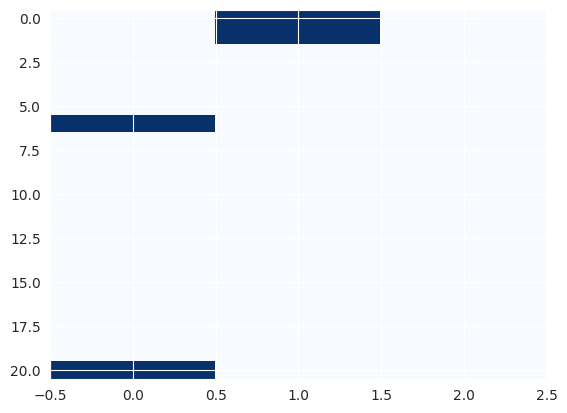

In [136]:
sec, n = 1, 1
dam_idx = sec*5 + n
ev_test = 41
raw_42 = X_signal[ev_test, dam_idx, :42]

n_rows, n_cols = shapes_used[(sec, n)]
img = np.zeros((n_rows, n_cols))
for (gx, gy), chans in lookup[(sec, n)].items():
    img[gx, gy] = raw_42[chans].sum()

plt.imshow(img, cmap="Blues", aspect="auto")

Secteur 0, DAM 0 (21, 3): conservation=True, manuel==vectorisé=True, shape ok=True  ->  OK
Secteur 0, DAM 1 (21, 3): conservation=True, manuel==vectorisé=True, shape ok=True  ->  OK
Secteur 0, DAM 2 (21, 3): conservation=True, manuel==vectorisé=True, shape ok=True  ->  OK
Secteur 0, DAM 3 (17, 4): conservation=True, manuel==vectorisé=True, shape ok=True  ->  OK
Secteur 0, DAM 4 (17, 4): conservation=True, manuel==vectorisé=True, shape ok=True  ->  OK
Secteur 1, DAM 0 (21, 3): conservation=True, manuel==vectorisé=True, shape ok=True  ->  OK
Secteur 1, DAM 1 (21, 3): conservation=True, manuel==vectorisé=True, shape ok=True  ->  OK
Secteur 1, DAM 2 (21, 3): conservation=True, manuel==vectorisé=True, shape ok=True  ->  OK
Secteur 1, DAM 3 (17, 4): conservation=True, manuel==vectorisé=True, shape ok=True  ->  OK
Secteur 1, DAM 4 (17, 4): conservation=True, manuel==vectorisé=True, shape ok=True  ->  OK
Secteur 2, DAM 0 (21, 3): conservation=True, manuel==vectorisé=True, shape ok=True  ->  OK

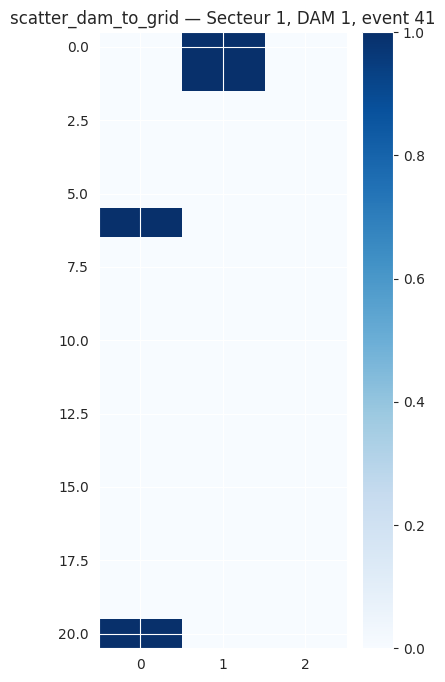

In [137]:
def build_all_dam_grids(X_signal, lookup, shapes_used, test_event=0, verbose=True):
    """
    Construit les grilles 2D pour les 30 DAM (6 secteurs x 5 DAM),
    et vérifie la cohérence entre méthode manuelle (cellule 19) et
    méthode vectorisée (scatter_dam_to_grid, cellule 17).

    Retourne :
        grids  : dict {(sec, n): img}  avec img de shape (N_events, n_rows, n_cols, 1)
        report : liste de tuples (sec, n, shape, conservation_ok, manuel_ok, shape_ok, status)
    """
    grids = {}
    report = []

    for (sec, n), cell_map in lookup.items():
        shape = shapes_used[(sec, n)]
        n_rows, n_cols = shape
        dam_idx = sec * 5 + n
        X_dam = X_signal[:, dam_idx, :42]

        # --- Méthode vectorisée (ta fonction) ---
        img = scatter_dam_to_grid(X_dam, cell_map, shape)
        grids[(sec, n)] = img

        # --- Vérif 1 : conservation du signal (somme image == somme des 42 canaux) ---
        conservation_ok = np.allclose(img.sum(axis=(1, 2, 3)), X_dam.sum(axis=1))

        # --- Vérif 2 : reproduction manuelle (cellule 19) sur un événement test ---
        raw = X_dam[test_event]
        img_manual = np.zeros((n_rows, n_cols))
        for (gx, gy), chans in cell_map.items():
            img_manual[gx, gy] = raw[chans].sum()
        manuel_ok = np.allclose(img[test_event, :, :, 0], img_manual)

        # --- Vérif 3 : la forme obtenue correspond bien à shapes_used ---
        shape_ok = img.shape[1:3] == shape

        status = "OK" if (conservation_ok and manuel_ok and shape_ok) else "PROBLEME"
        report.append((sec, n, shape, conservation_ok, manuel_ok, shape_ok, status))

        if verbose:
            print(f"Secteur {sec}, DAM {n} {shape}: "
                  f"conservation={conservation_ok}, manuel==vectorisé={manuel_ok}, "
                  f"shape ok={shape_ok}  ->  {status}")

    return grids, report


# Utilisation :
grids, report = build_all_dam_grids(X_signal, lookup, shapes_used, test_event=41)

# Exemple : comparer visuellement la DAM (sec=1, n=1) reconstruite par ta fonction
# vs la version manuelle de la cellule 19, pour le même événement
sec, n, ev = 1, 1, 41
plt.figure(figsize=(4, 8))
plt.imshow(grids[(sec, n)][ev, :, :, 0], cmap="Blues", aspect="auto")
plt.title(f"scatter_dam_to_grid — Secteur {sec}, DAM {n}, event {ev}")
plt.colorbar()
plt.show()

In [120]:
#df_time_noise = [df_rec["event"] == 100]
df_time_events = df_rec_last#[df_rec_1["event"] == 100]
df_time_noise = df_noise#[df_rec["event"] <= 19]

print(df_time_noise)
print(df_sim_last)

        event           cell_id  sector      time  charge  pindex          gx  \
0           0   844437823631480       0  3.243210     280       0  121.118037   
1           0   281500763506808       0  4.347658     280       0  133.917953   
2           0  1970324837204088       0  5.505122     280       0  147.633894   
3           0   281500755136632       0  8.036306     280       0  103.516252   
4           0   281474985341048       0  3.474702     280       0  112.618552   
...       ...               ...     ...       ...     ...     ...         ...   
483185    999  1125929980179832       5  5.304399     280       0  130.041716   
483186    999   281475002054008       5  8.491590     280       0  129.858961   
483187    999   281500755086712       5  1.739241     280       0  121.098861   
483188    999   281483583608184       5  8.047181     280       0  118.204938   
483189    999  1125899932198264       5  3.941418     280       0  114.136027   

                gy         

In [121]:
import os

# cartella output per i plot
OUTDIR = "report_plots_histo"
os.makedirs(OUTDIR, exist_ok=True)

In [122]:
import os
import pandas as pd
import numpy as np
import time

nfiles = 800
df_rec_signal_list = []
df_index = 0
new_file_init = True

start = time.perf_counter()

for f in range(nfiles):
    print(f"SIGNAL FILE n.{f}")

    #file_string = f"Bkg_1SignalPer2usframe_2601/rec_hits_{f+1:04d}.csv"
    file_string = f"/content/drive/MyDrive/project_files/Bkg_new/rec_hits_{f+1:04d}.csv"

    if not os.path.exists(file_string):
        print(file_string + " skipped!")
        continue

    # Leggi CSV
    df_rec_signal = pd.read_csv(file_string, sep=',')

    # Salta DataFrame vuoti o senza colonna "event"
    if df_rec_signal.empty or "event" not in df_rec_signal.columns:
        continue

    # Riallinea eventi locali partendo da 0
    df_rec_signal["event"] = df_rec_signal.groupby("event", sort=False).ngroup()

    # Converte a intero per sicurezza
    df_rec_signal["event"] = df_rec_signal["event"].astype(int)

    nevents = df_rec_signal["event"].max()

    if new_file_init:
        # Split se supera 999
        if nevents > 999:
            df1 = df_rec_signal[df_rec_signal["event"] <= 999].copy()
            df2 = df_rec_signal[df_rec_signal["event"] > 999].copy()

            if not df2.empty:
                df2["event"] = (df2["event"] - df2["event"].min()) % 1000
                df2["event"] = df2["event"].astype(int)

            df_rec_signal_list.append(df1)
            df_index += 1
            df_rec_signal_list.append(df2)
        else:
            df_rec_signal_list.append(df_rec_signal)
        new_file_init = False
    else:
        # Offset globale rispetto al precedente, modulo 1000 per wrap
        df_previous = df_rec_signal_list[df_index]
        prev_max = df_previous["event"].max() if not df_previous.empty else -1
        df_rec_signal["event"] = (df_rec_signal["event"] + prev_max + 1)# % 1000
        df_rec_signal["event"] = df_rec_signal["event"].astype(int)

        # Concatenate temporanea
        df_conc = pd.concat([df_previous, df_rec_signal], ignore_index=True)
        nev = df_conc["event"].max()

        if nev > 999:
            df1 = df_conc[df_conc["event"] <= 999].copy()
            df2 = df_conc[df_conc["event"] > 999].copy()

            if not df2.empty:
                df2["event"] = (df2["event"] - df2["event"].min()) % 1000
                df2["event"] = df2["event"].astype(int)

            df_rec_signal_list[df_index] = df1
            df_index += 1
            df_rec_signal_list.append(df2)
            new_file_init = False
        else:
            df_rec_signal_list[df_index] = df_conc
            if nev == 999:
                new_file_init = True

end = time.perf_counter()
print(f"Tempo totale merging SIG+NOISE: {end - start:.4f}s")

SIGNAL FILE n.0
SIGNAL FILE n.1
SIGNAL FILE n.2
SIGNAL FILE n.3
SIGNAL FILE n.4
SIGNAL FILE n.5
SIGNAL FILE n.6
SIGNAL FILE n.7
SIGNAL FILE n.8
SIGNAL FILE n.9
SIGNAL FILE n.10
SIGNAL FILE n.11
SIGNAL FILE n.12
SIGNAL FILE n.13
SIGNAL FILE n.14
SIGNAL FILE n.15
SIGNAL FILE n.16
SIGNAL FILE n.17
SIGNAL FILE n.18
SIGNAL FILE n.19
SIGNAL FILE n.20
SIGNAL FILE n.21
SIGNAL FILE n.22
SIGNAL FILE n.23
SIGNAL FILE n.24
SIGNAL FILE n.25
SIGNAL FILE n.26
SIGNAL FILE n.27
SIGNAL FILE n.28
SIGNAL FILE n.29
SIGNAL FILE n.30
SIGNAL FILE n.31
SIGNAL FILE n.32
SIGNAL FILE n.33
SIGNAL FILE n.34
SIGNAL FILE n.35
SIGNAL FILE n.36
SIGNAL FILE n.37
SIGNAL FILE n.38
SIGNAL FILE n.39
SIGNAL FILE n.40
SIGNAL FILE n.41
SIGNAL FILE n.42
SIGNAL FILE n.43
SIGNAL FILE n.44
SIGNAL FILE n.45
SIGNAL FILE n.46
SIGNAL FILE n.47
SIGNAL FILE n.48
SIGNAL FILE n.49
SIGNAL FILE n.50
SIGNAL FILE n.51
SIGNAL FILE n.52
SIGNAL FILE n.53
SIGNAL FILE n.54
SIGNAL FILE n.55
SIGNAL FILE n.56
SIGNAL FILE n.57
SIGNAL FILE n.58
SIGNAL 

In [123]:
print(df_rec_signal_list[0][df_rec_signal_list[0]["event"]==41])

      event           cell_id  sector   time  charge  pindex          gx  \
4500     41  1688862753961080       4  11105     297   53621    4.713220   
4501     41   844442110405752       4  11105     298   53633    6.632357   
4502     41       12910472312       4  11106     275   53379    8.390403   
4503     41  1970337739058296       4  11106     273   53379    8.031935   
4504     41  1407392088992888       4  11106     264      31   10.001139   
...     ...               ...     ...    ...     ...     ...         ...   
4724     41  1970329140401016       3  11123     264   53621 -164.361664   
4725     41  1125908513638776       1  11123     285   53633  -27.809305   
4726     41             56696       5  11124     274   53622  140.065353   
4727     41   281487870055800       5  11124     303   53622  145.098465   
4728     41  1688867057003896       5  11124     266   53622  145.824539   

              gy          gz   lx   ly  pdu  sipm  xi  yi  
4500 -116.784958  225.83949

In [124]:
import time
from time import perf_counter
sig_times = []

for ev in range(max(df_rec_signal_list[0]["event"])):
    ev=ev+1
    #print(ev)
    start = perf_counter()
    df = df_rec_signal_list[0][df_rec_signal_list[0]["event"]==ev]
    min_time = min(df["time"])
    # questo era quello originale 1/2                         time_col = ((df["time"]-min_time))/16)%20.32
    time_col = ((df["time"]-min_time))
    #time_col = (df["time"]/16)%20.32
    if (ev==1):
        sig_times = time_col
    else:
        df_previous = sig_times
        sig_times =  pd.concat([df_previous, time_col])
    end = perf_counter()
    if(ev%100 == 0):
        print(f"Tempo totale per eventp: {end - start:.4f}s")



Tempo totale per eventp: 0.0006s
Tempo totale per eventp: 0.0006s
Tempo totale per eventp: 0.0006s
Tempo totale per eventp: 0.0006s
Tempo totale per eventp: 0.0006s
Tempo totale per eventp: 0.0006s
Tempo totale per eventp: 0.0008s
Tempo totale per eventp: 0.0010s
Tempo totale per eventp: 0.0007s


135       0
136       0
137       1
138       1
139       1
         ..
108342    2
108343    3
108344    3
108345    3
108346    4
Name: time, Length: 108212, dtype: int64
0          2485
1          2485
2          2485
3          2485
4          2485
          ...  
108342    20398
108343    20399
108344    20399
108345    20399
108346    20400
Name: time, Length: 108347, dtype: int64
483190
108347
[ 0.    2.54  5.08  7.62 10.16]
Set di estremi dei bin utilizzati
[ 0.    2.54  5.08  7.62 10.16]
[120753. 121025. 120519. 120893.]
598.0074257425742
Integrale Signal: 57496.0
Integrale Noise: 483190.0
Salvato: report_plots_histo/histogram_dcr300kHz_Bin2.54ns.png


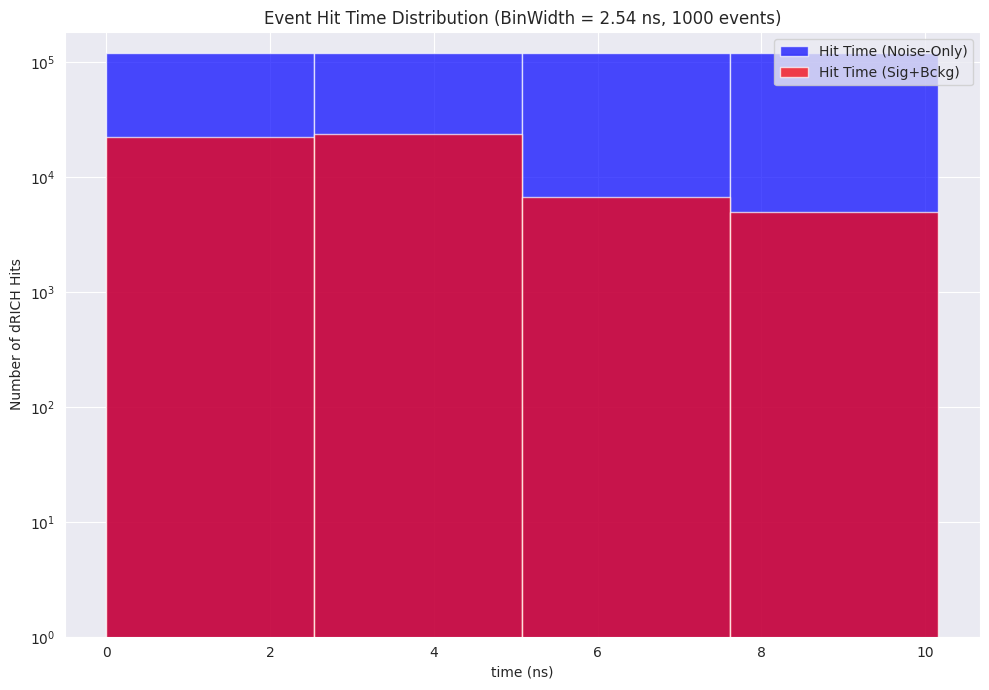

[ 0.    1.27  2.54  3.81  5.08  6.35  7.62  8.89 10.16]
Set di estremi dei bin utilizzati
[ 0.    1.27  2.54  3.81  5.08  6.35  7.62  8.89 10.16]
[60354. 60399. 60361. 60664. 60536. 59983. 60319. 60574.]
299.0037128712871
Integrale Signal: 57496.0
Integrale Noise: 483190.0
Salvato: report_plots_histo/histogram_dcr300kHz_Bin1.27ns.png


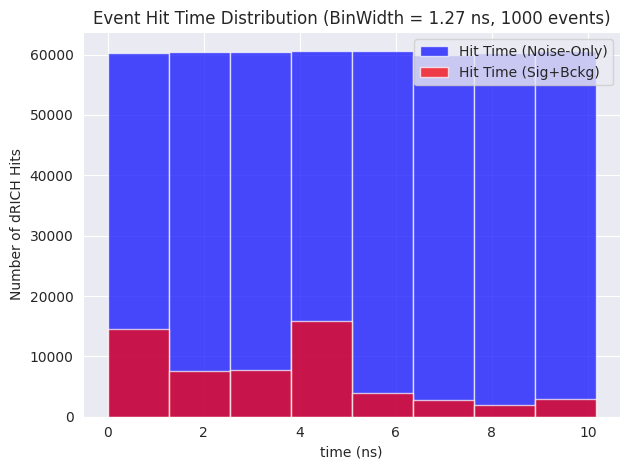

[ 0.     0.635  1.27   1.905  2.54   3.175  3.81   4.445  5.08   5.715
  6.35   6.985  7.62   8.255  8.89   9.525 10.16 ]
Set di estremi dei bin utilizzati
[ 0.     0.635  1.27   1.905  2.54   3.175  3.81   4.445  5.08   5.715
  6.35   6.985  7.62   8.255  8.89   9.525 10.16 ]
[30335. 30019. 30025. 30374. 30235. 30126. 30404. 30260. 30212. 30324.
 30041. 29942. 30053. 30266. 30280. 30294.]
149.50185643564356
Integrale Signal: 57496.0
Integrale Noise: 483190.0
Salvato: report_plots_histo/histogram_dcr300kHz_Bin0.635ns.png


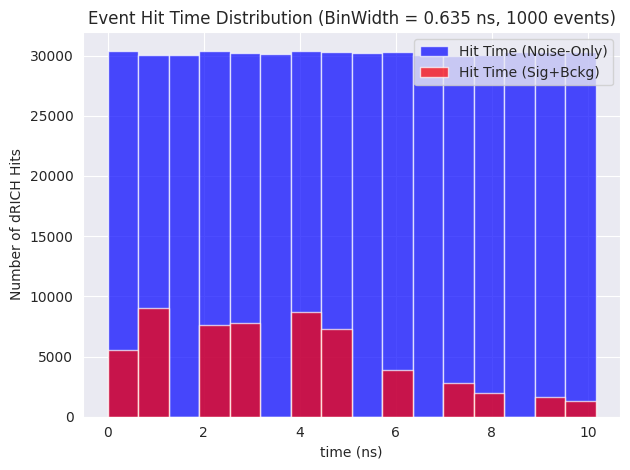

[ 0.      0.3175  0.635   0.9525  1.27    1.5875  1.905   2.2225  2.54
  2.8575  3.175   3.4925  3.81    4.1275  4.445   4.7625  5.08    5.3975
  5.715   6.0325  6.35    6.6675  6.985   7.3025  7.62    7.9375  8.255
  8.5725  8.89    9.2075  9.525   9.8425 10.16  ]
Set di estremi dei bin utilizzati
[ 0.      0.3175  0.635   0.9525  1.27    1.5875  1.905   2.2225  2.54
  2.8575  3.175   3.4925  3.81    4.1275  4.445   4.7625  5.08    5.3975
  5.715   6.0325  6.35    6.6675  6.985   7.3025  7.62    7.9375  8.255
  8.5725  8.89    9.2075  9.525   9.8425 10.16  ]
[15150. 15185. 14992. 15027. 14990. 15035. 15181. 15193. 15095. 15140.
 15080. 15046. 15402. 15002. 15223. 15037. 15219. 14993. 15277. 15047.
 15052. 14989. 15104. 14838. 15013. 15040. 15203. 15063. 15046. 15234.
 15086. 15208.]
74.75092821782178
Integrale Signal: 57496.0
Integrale Noise: 483190.0
Salvato: report_plots_histo/histogram_dcr300kHz_Bin0.3175ns.png


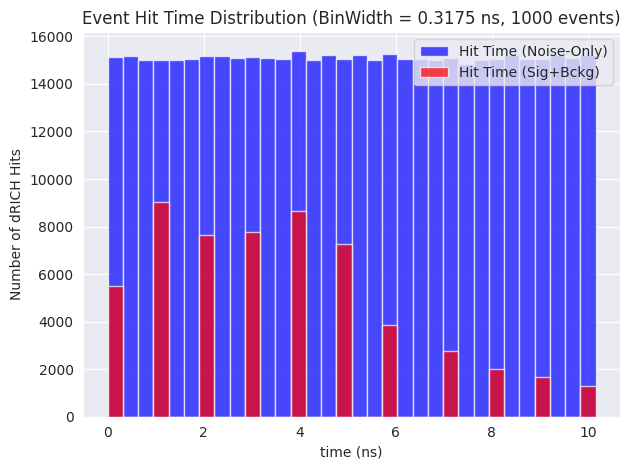

[ 0.       0.15875  0.3175   0.47625  0.635    0.79375  0.9525   1.11125
  1.27     1.42875  1.5875   1.74625  1.905    2.06375  2.2225   2.38125
  2.54     2.69875  2.8575   3.01625  3.175    3.33375  3.4925   3.65125
  3.81     3.96875  4.1275   4.28625  4.445    4.60375  4.7625   4.92125
  5.08     5.23875  5.3975   5.55625  5.715    5.87375  6.0325   6.19125
  6.35     6.50875  6.6675   6.82625  6.985    7.14375  7.3025   7.46125
  7.62     7.77875  7.9375   8.09625  8.255    8.41375  8.5725   8.73125
  8.89     9.04875  9.2075   9.36625  9.525    9.68375  9.8425  10.00125]
Set di estremi dei bin utilizzati
[ 0.       0.15875  0.3175   0.47625  0.635    0.79375  0.9525   1.11125
  1.27     1.42875  1.5875   1.74625  1.905    2.06375  2.2225   2.38125
  2.54     2.69875  2.8575   3.01625  3.175    3.33375  3.4925   3.65125
  3.81     3.96875  4.1275   4.28625  4.445    4.60375  4.7625   4.92125
  5.08     5.23875  5.3975   5.55625  5.715    5.87375  6.0325   6.19125
  6.35     6.508

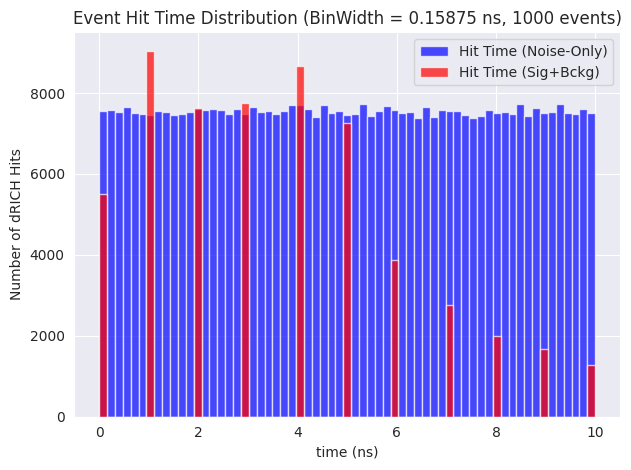

[ 0.        0.079375  0.15875   0.238125  0.3175    0.396875  0.47625
  0.555625  0.635     0.714375  0.79375   0.873125  0.9525    1.031875
  1.11125   1.190625  1.27      1.349375  1.42875   1.508125  1.5875
  1.666875  1.74625   1.825625  1.905     1.984375  2.06375   2.143125
  2.2225    2.301875  2.38125   2.460625  2.54      2.619375  2.69875
  2.778125  2.8575    2.936875  3.01625   3.095625  3.175     3.254375
  3.33375   3.413125  3.4925    3.571875  3.65125   3.730625  3.81
  3.889375  3.96875   4.048125  4.1275    4.206875  4.28625   4.365625
  4.445     4.524375  4.60375   4.683125  4.7625    4.841875  4.92125
  5.000625  5.08      5.159375  5.23875   5.318125  5.3975    5.476875
  5.55625   5.635625  5.715     5.794375  5.87375   5.953125  6.0325
  6.111875  6.19125   6.270625  6.35      6.429375  6.50875   6.588125
  6.6675    6.746875  6.82625   6.905625  6.985     7.064375  7.14375
  7.223125  7.3025    7.381875  7.46125   7.540625  7.62      7.699375
  7.77875   7.8581

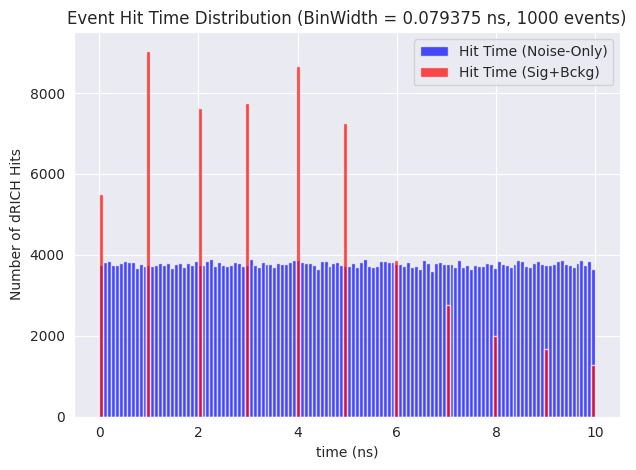

[ 0.         0.0396875  0.079375   0.1190625  0.15875    0.1984375
  0.238125   0.2778125  0.3175     0.3571875  0.396875   0.4365625
  0.47625    0.5159375  0.555625   0.5953125  0.635      0.6746875
  0.714375   0.7540625  0.79375    0.8334375  0.873125   0.9128125
  0.9525     0.9921875  1.031875   1.0715625  1.11125    1.1509375
  1.190625   1.2303125  1.27       1.3096875  1.349375   1.3890625
  1.42875    1.4684375  1.508125   1.5478125  1.5875     1.6271875
  1.666875   1.7065625  1.74625    1.7859375  1.825625   1.8653125
  1.905      1.9446875  1.984375   2.0240625  2.06375    2.1034375
  2.143125   2.1828125  2.2225     2.2621875  2.301875   2.3415625
  2.38125    2.4209375  2.460625   2.5003125  2.54       2.5796875
  2.619375   2.6590625  2.69875    2.7384375  2.778125   2.8178125
  2.8575     2.8971875  2.936875   2.9765625  3.01625    3.0559375
  3.095625   3.1353125  3.175      3.2146875  3.254375   3.2940625
  3.33375    3.3734375  3.413125   3.4528125  3.4925     3.532

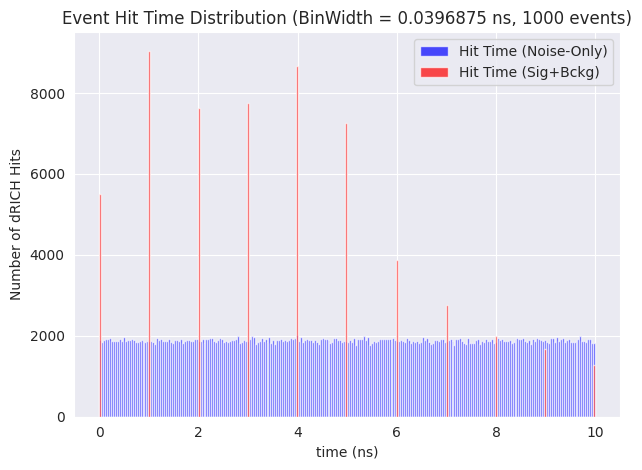

In [125]:
fig, ax = plt.subplots(figsize=(10,7))

ax.grid(True)

a = df_time_noise["time"]
#b = (df_time_events["time"]*16)-(((df_time_events["time"]*16)//10.16)*10.16)
#  questo era quello orginale 2/2
# b = df_rec_signal_list[0]["time"]/16#(df_rec_signal_list[0]["time"]/16)-(((df_rec_signal_list[0]["time"]/16)//20.32)*20.32)
b = df_rec_signal_list[0]["time"]
print(sig_times)
print(b)


e = df_time_events["event"].max()
print(a.size)
print(b.size)

#bins = np.histogram(np.hstack((a,b)), bins=50)[1]
for exp in range(7):
    BIN_MIN = 0
    DCR = 300 #kHz
    BIN_MAX = 10
    BIN_WIDTH = 2.54/pow(2,exp)

    bins = np.arange(BIN_MIN, BIN_MAX + BIN_WIDTH, BIN_WIDTH)
    nbins = len(bins) - 1

    print(bins)
    n1, bins1, _ = plt.hist(a, bins=bins, alpha=0.7, label='Hit Time (Noise-Only)', color='blue')
    n0, bins0, _ = plt.hist(sig_times, bins=bins, alpha=0.7, label='Hit Time (Sig+Bckg)', color='red',)



    # Calcola integrali degli istogrammi
    print("Set di estremi dei bin utilizzati")
    print(bins0)
    print(n1)
    print(n1.mean()/e)

    integrale_noise = np.sum(n0)# * np.diff(bins))*len(bins)
    integrale_noise1 = np.sum(n1)# * np.diff(bins))*len(bins)
    # Stampa risultati
    print(f"Integrale Signal: {integrale_noise}")
    print(f"Integrale Noise: {integrale_noise1}")

    ax.set_yscale('log')
    #ax.set_xscale('log')
    ax.set_ylim(1,1.5*max([max(n0),max(n1)]))

    plt.xlabel('time (ns)')
    plt.ylabel('Number of dRICH Hits')
    plt.title(f'Event Hit Time Distribution (BinWidth = {BIN_WIDTH} ns, 1000 events)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    out = f"{OUTDIR}/histogram_dcr{DCR}kHz_Bin{BIN_WIDTH}ns.png"
    plt.savefig(out, dpi=200)
    print("Salvato:", out)


    plt.show()

In [126]:
import os
import pandas as pd
import numpy as np
import time

nfiles = 582
df_sim_signal_list = []
df_index = 0
new_file_init = True

start = time.perf_counter()
print(f"SIMULATION DATASET")
for f in range(nfiles):
    print(f"SIGNAL FILE n.{f}")

    file_string = f"/content/drive/MyDrive/project_files/Bkg_new/sim_parts_{f+1:04d}.csv"

    if not os.path.exists(file_string):
        print(file_string + " skipped!")
        continue

    # Leggi CSV
    df_sim_signal = pd.read_csv(file_string, sep=',')

    # Salta DataFrame vuoti o senza colonna "event"
    if df_sim_signal.empty or "event" not in df_sim_signal.columns:
        continue

    # Riallinea eventi locali partendo da 0
    df_sim_signal["event"] = df_sim_signal.groupby("event", sort=False).ngroup()

    # Converte a intero per sicurezza
    df_sim_signal["event"] = df_sim_signal["event"].astype(int)

    nevents = df_sim_signal["event"].max()

    if new_file_init:
        # Split se supera 999
        if nevents > 999:
            df1 = df_sim_signal[df_sim_signal["event"] <= 999].copy()
            df2 = df_sim_signal[df_sim_signal["event"] > 999].copy()

            if not df2.empty:
                df2["event"] = (df2["event"] - df2["event"].min()) % 1000
                df2["event"] = df2["event"].astype(int)

            df_sim_signal_list.append(df1)
            df_index += 1
            df_sim_signal_list.append(df2)
        else:
            df_sim_signal_list.append(df_rec_signal)
        new_file_init = False
    else:
        # Offset globale rispetto al precedente, modulo 1000 per wrap
        df_previous = df_sim_signal_list[df_index]
        prev_max = df_previous["event"].max() if not df_previous.empty else -1
        df_sim_signal["event"] = (df_sim_signal["event"] + prev_max + 1)# % 1000
        df_sim_signal["event"] = df_sim_signal["event"].astype(int)

        # Concatenate temporanea
        df_conc = pd.concat([df_previous, df_sim_signal], ignore_index=True)
        nev = df_conc["event"].max()

        if nev > 999:
            df1 = df_conc[df_conc["event"] <= 999].copy()
            df2 = df_conc[df_conc["event"] > 999].copy()

            if not df2.empty:
                df2["event"] = (df2["event"] - df2["event"].min()) % 1000
                df2["event"] = df2["event"].astype(int)

            df_sim_signal_list[df_index] = df1
            df_index += 1
            df_sim_signal_list.append(df2)
            new_file_init = False
        else:
            df_sim_signal_list[df_index] = df_conc
            if nev == 999:
                new_file_init = True

end = time.perf_counter()
print(f"Tempo totale merging SIG+NOISE: {end - start:.4f}s")

SIMULATION DATASET
SIGNAL FILE n.0
/content/drive/MyDrive/project_files/Bkg_new/sim_parts_0001.csv skipped!
SIGNAL FILE n.1
SIGNAL FILE n.2
SIGNAL FILE n.3
SIGNAL FILE n.4
/content/drive/MyDrive/project_files/Bkg_new/sim_parts_0005.csv skipped!
SIGNAL FILE n.5
SIGNAL FILE n.6
SIGNAL FILE n.7
/content/drive/MyDrive/project_files/Bkg_new/sim_parts_0008.csv skipped!
SIGNAL FILE n.8
SIGNAL FILE n.9
/content/drive/MyDrive/project_files/Bkg_new/sim_parts_0010.csv skipped!
SIGNAL FILE n.10
SIGNAL FILE n.11
/content/drive/MyDrive/project_files/Bkg_new/sim_parts_0012.csv skipped!
SIGNAL FILE n.12
SIGNAL FILE n.13
SIGNAL FILE n.14
SIGNAL FILE n.15
/content/drive/MyDrive/project_files/Bkg_new/sim_parts_0016.csv skipped!
SIGNAL FILE n.16
SIGNAL FILE n.17
SIGNAL FILE n.18
/content/drive/MyDrive/project_files/Bkg_new/sim_parts_0019.csv skipped!
SIGNAL FILE n.19
/content/drive/MyDrive/project_files/Bkg_new/sim_parts_0020.csv skipped!
SIGNAL FILE n.20
SIGNAL FILE n.21
/content/drive/MyDrive/project_fi

In [127]:
print(len(df_rec_signal_list))
print(len(df_sim_signal_list))

#print(df_rec_signal_list[88])

#tutti i """"file"""

154
78


      event           cell_id  sector   time  charge  pindex          gx  \
3969     42   844424930515832       3  14200     297   54572 -107.264381   
3970     42   281487886928248       1  14277     264   54572   35.823589   
3971     42   562980026763384       0  14286     293   54572  142.111313   
3972     42       25778226040       3  14288     276   54571 -118.933273   
3973     42  1970350632368760       2  16150     302   54571  -99.826340   
...     ...               ...     ...    ...     ...     ...         ...   
4394     42   844437823447672       2  16171     266   54571 -137.895508   
4395     42   281474993752696       2  16173     272   54571 -100.689011   
4396     42   562962863577976       3  16180     310   54572 -132.753494   
4397     42   562980026743928       4  16181     270   54572   33.831642   
4398     42       17205117816       3  16185     269   54572 -125.294785   

              gy          gz   lx   ly  pdu  sipm  xi  yi  
3969  -55.133961  228.46052

/tmp/ipykernel_2920/2336447550.py:45: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(


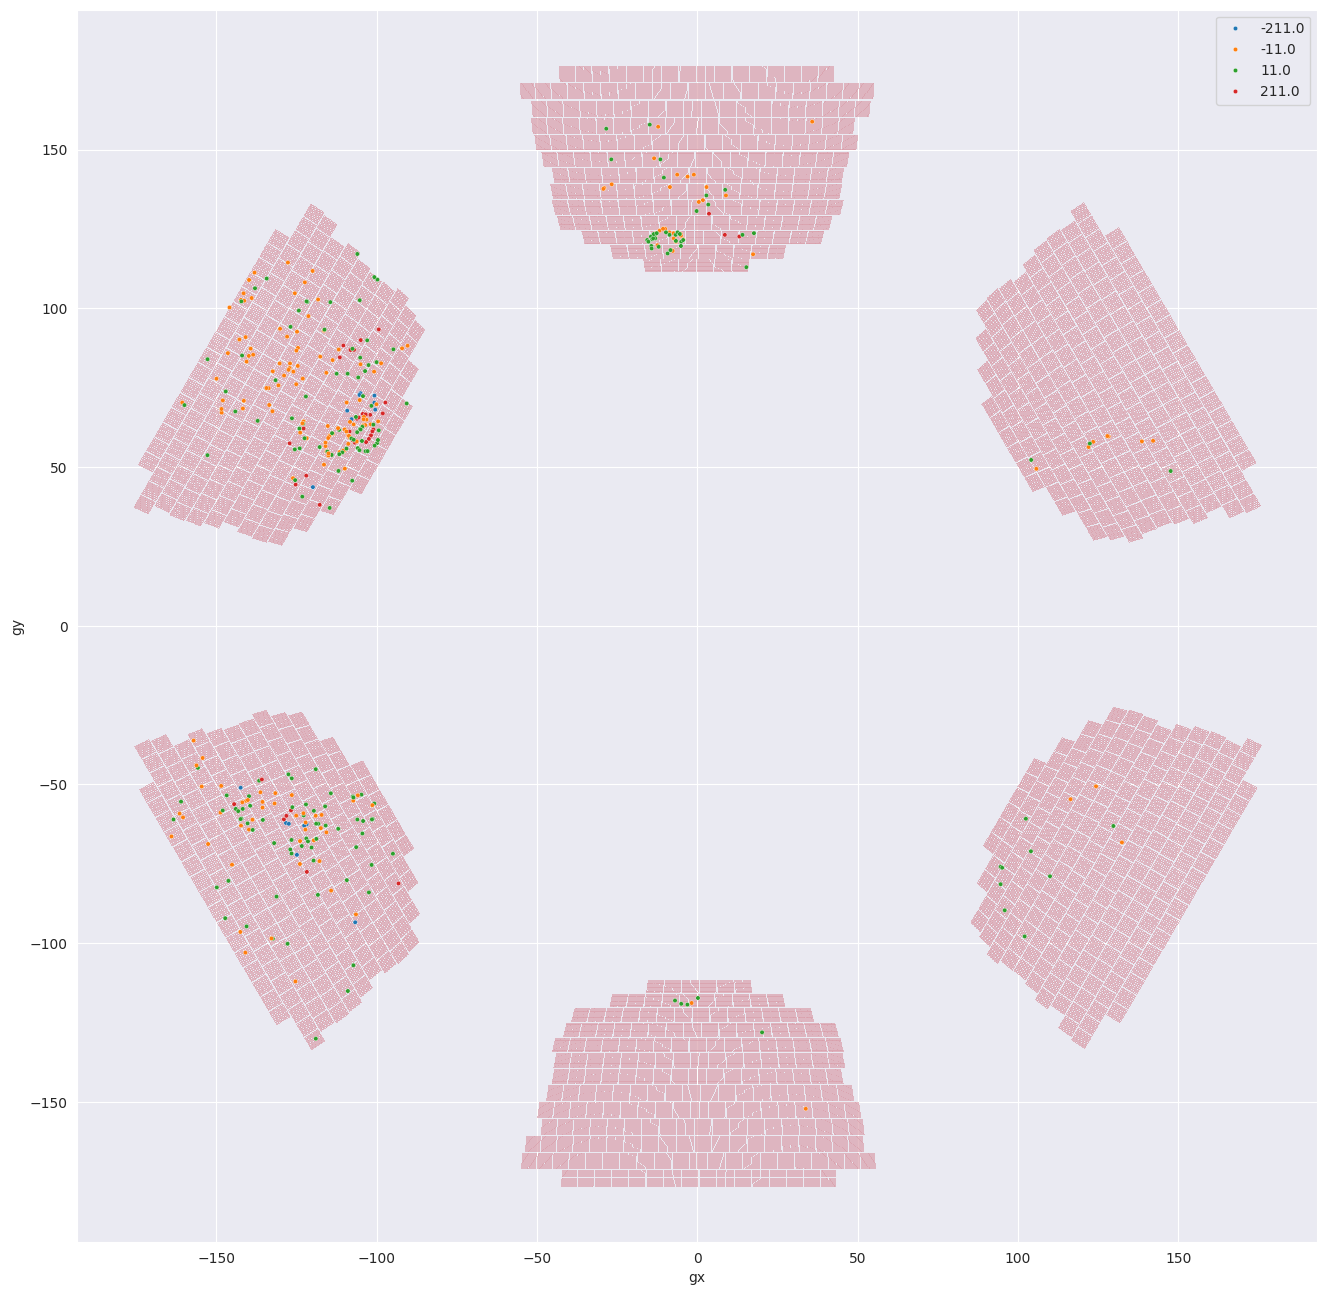

In [128]:
# Plot entire dRICH + hits from event 15 in the EIC global coordinate system.
plt.figure(figsize=(16, 16))
global2d_plotcells(df_cellmap)


id_event = 42
id_file = 2
id1="" if id_file>10 else "0"
id2="" if id_file>100 else "0"
id3="" if id_file>1000 else "0"
#df_rec_last     = pd.read_csv(f"Bkg_1SignalPer2usframe_2601/rec_hits_{id3}{id2}{id1}{id_file}.csv", sep = ',')
df_rec_last     = pd.read_csv(f"/content/drive/MyDrive/project_files/Bkg_new//rec_hits_{id3}{id2}{id1}{id_file}.csv", sep = ',')
df_sim_last     = pd.read_csv(f"/content/drive/MyDrive/project_files/Bkg_new/sim_parts_{id3}{id2}{id1}{id_file}.csv", sep = ',')
df_rec_show = df_rec_last
df_sim_show = df_sim_last

df_rec_show = df_rec_last
df_sim_show = df_sim_last

rf = df_rec_show[df_rec_show["event"] == id_event]
sf = df_sim_show[df_sim_show["event"] == id_event]
print(rf)
print(sf)

#global2d_plothits_timing(df_rec_last, 0)
global2d_plothits_tag(df_rec_show, df_sim_show, id_event)
plt.show()

In [129]:
# ROBA NUOVA
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
# ROBA NUOVA

In [130]:
def global2d_plothits_tag_v(df, tf, ei):
    df = df[df["event"] == ei]
    tf = tf[tf["event"] == ei]
    massimo=max(df["time"])
    minimo=min(df["time"])
    t_tot=[]
    x_tot=[]
    y_tot=[]
    hue_tot=[]
    for t in df["time"].unique():
        x_a=[]
        y_a=[]
        dfi = df[df["time"] == t]
        hue_a=[]
        for idx, row in dfi.iterrows():
            x_a.append(row["gx"])
            y_a.append(row["gy"])
            if(row["pindex"]==0):
                #print("NOISE")
                hue_a.append(0)
            else:
                for idx_t, row_t in tf.iterrows():
                    if(row["pindex"]==row_t["pindex"]):
                        #print("MATCH!")
                        hue_a.append(row_t["pdg"])
                        #print(row_t["pdg"])
                        break
        t_tot.append(t)
        x_tot.append(x_a)
        y_tot.append(y_a)
        hue_tot.append(hue_a)
    #print(np.asarray(x_tot).shape)
    #print(np.asarray(y_tot).shape)
    #print(np.asarray(hue_tot).shape)
    return t_tot,x_tot,y_tot,hue_tot
    #sns.scatterplot(
    #    x = x_a, y = y_a,
    #    s = 10, hue = hue_a, palette =  sns.color_palette()
    #)


In [131]:
def plot_(x_a,y_a,hue_a):
    sns.scatterplot(
        x = x_a, y = y_a,
        s = 10, hue = hue_a, palette =  sns.color_palette()
    )

FILE #2
EVENT #42
START


#:	0		t:	14200 ns		#hits:	1


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (1), which may not be intended.
  sns.scatterplot(


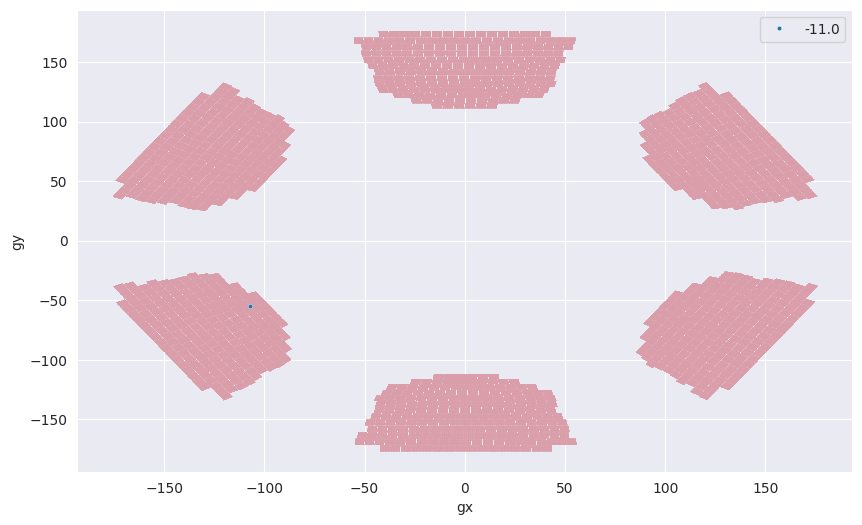

#:	1		t:	14277 ns		#hits:	1


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (1), which may not be intended.
  sns.scatterplot(


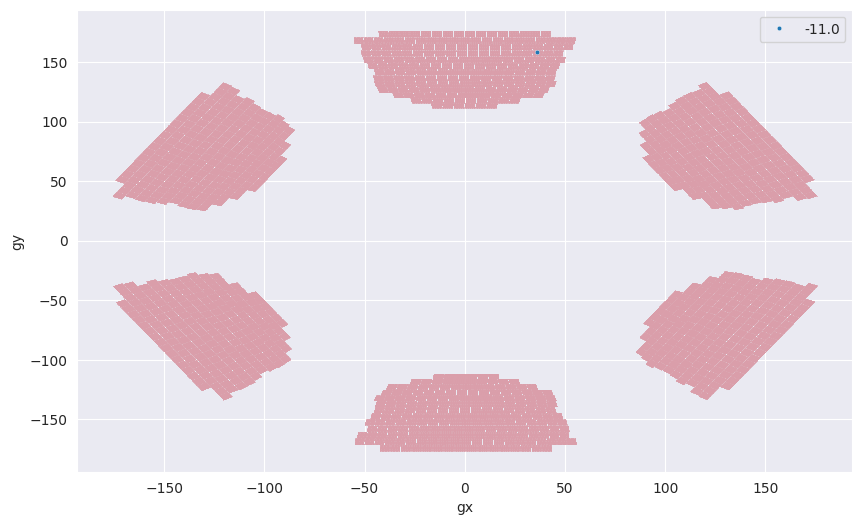

#:	2		t:	14286 ns		#hits:	1


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (1), which may not be intended.
  sns.scatterplot(


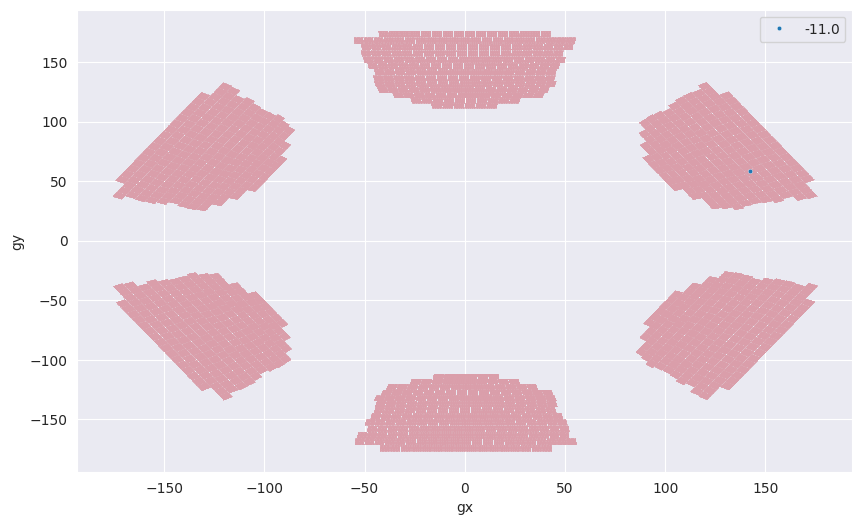

#:	3		t:	14288 ns		#hits:	1


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (1), which may not be intended.
  sns.scatterplot(


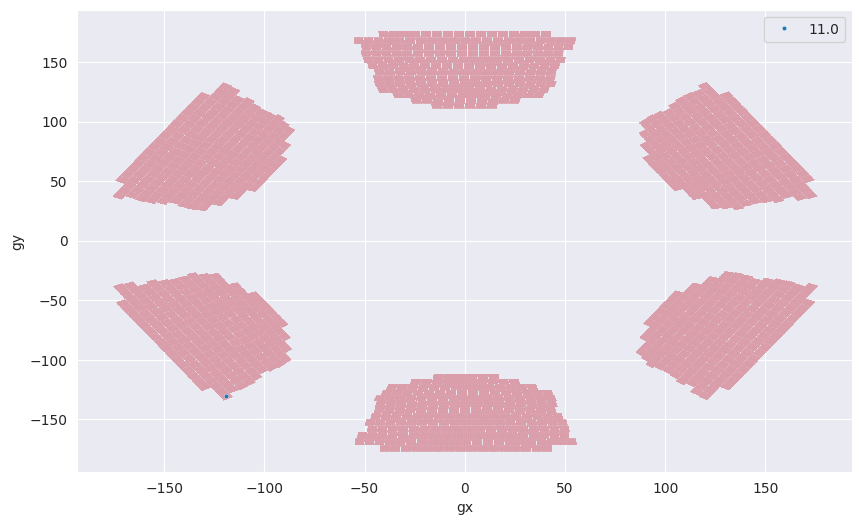

#:	4		t:	16150 ns		#hits:	7


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (1), which may not be intended.
  sns.scatterplot(


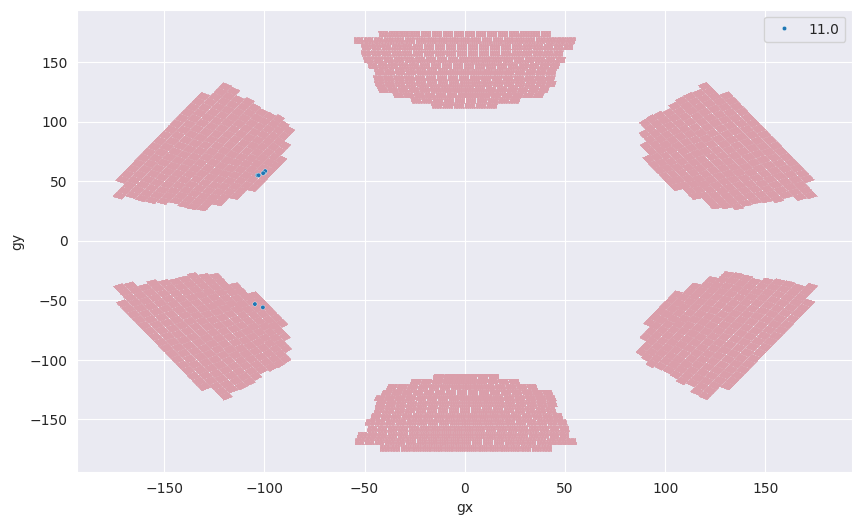

#:	5		t:	16151 ns		#hits:	142


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(


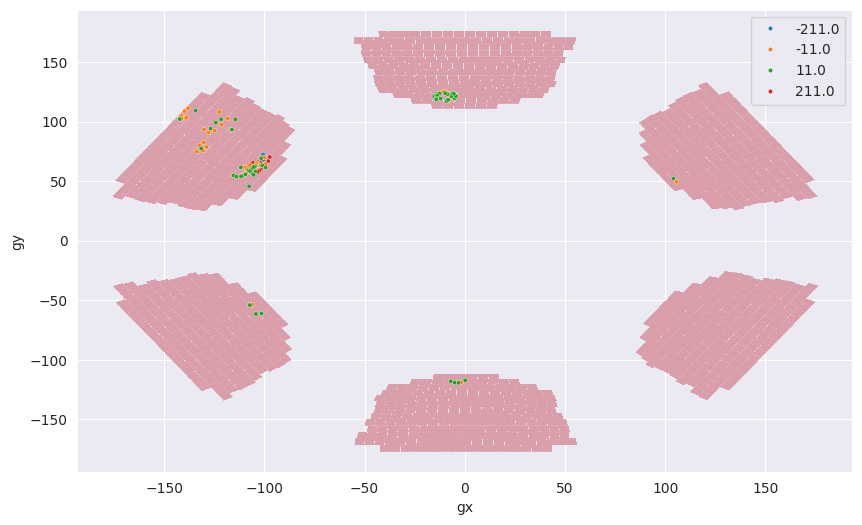

#:	6		t:	16152 ns		#hits:	70


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(


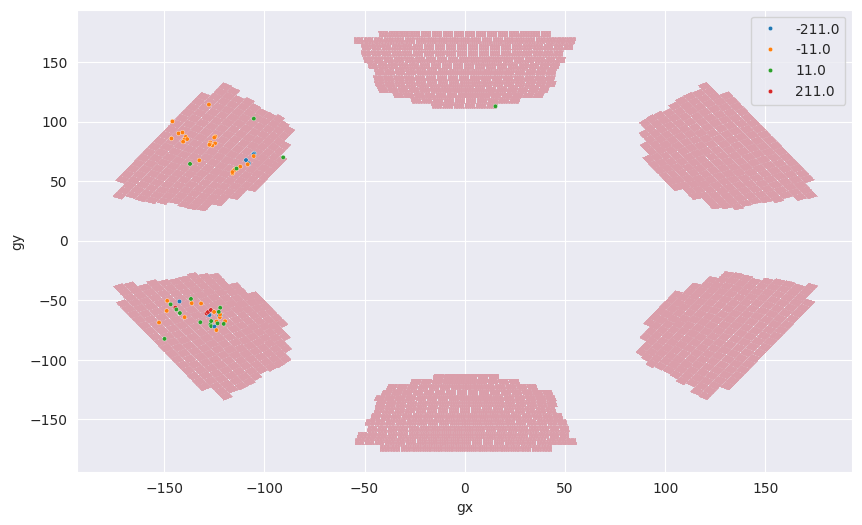

#:	7		t:	16153 ns		#hits:	35


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(


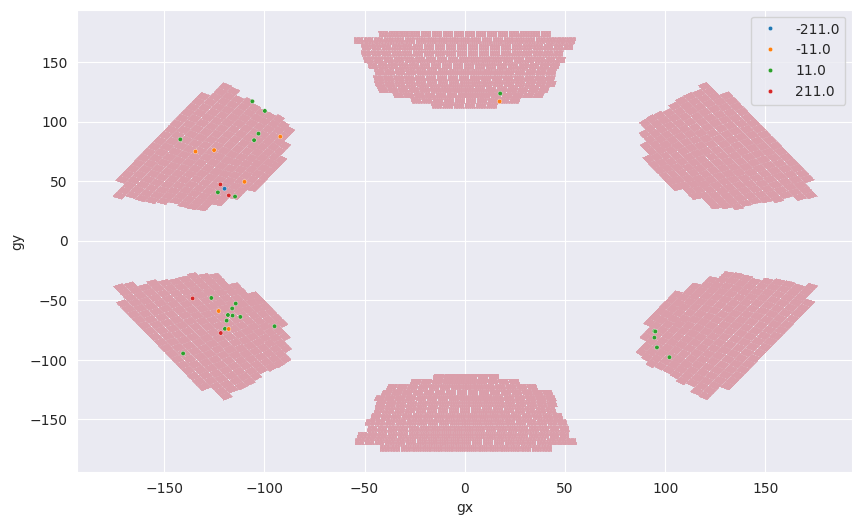

#:	8		t:	16154 ns		#hits:	59


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(


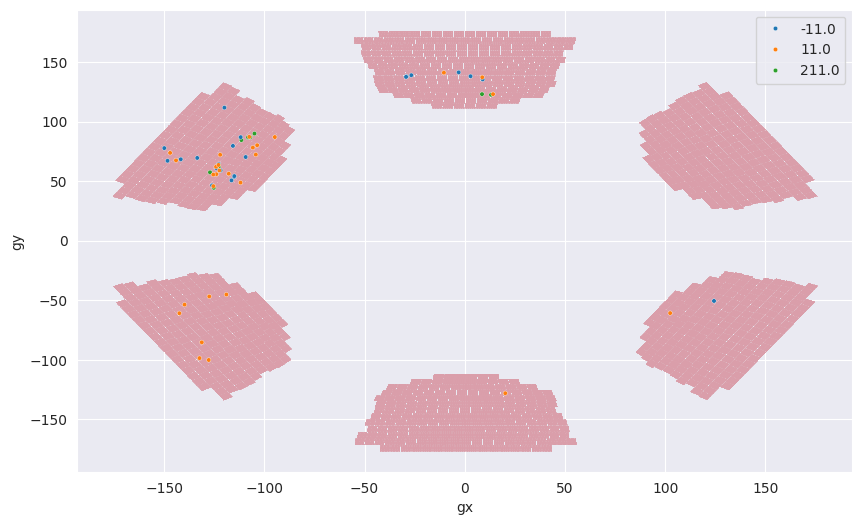

#:	9		t:	16155 ns		#hits:	47


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(


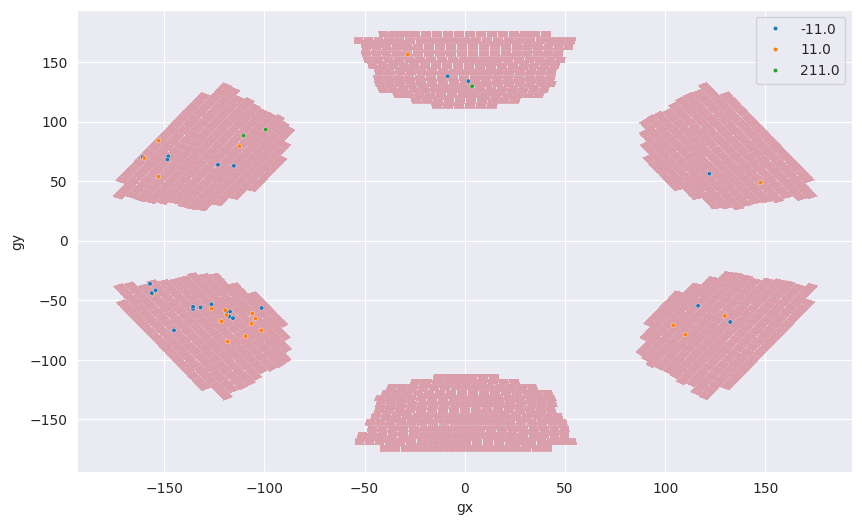

#:	10		t:	16156 ns		#hits:	27


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(


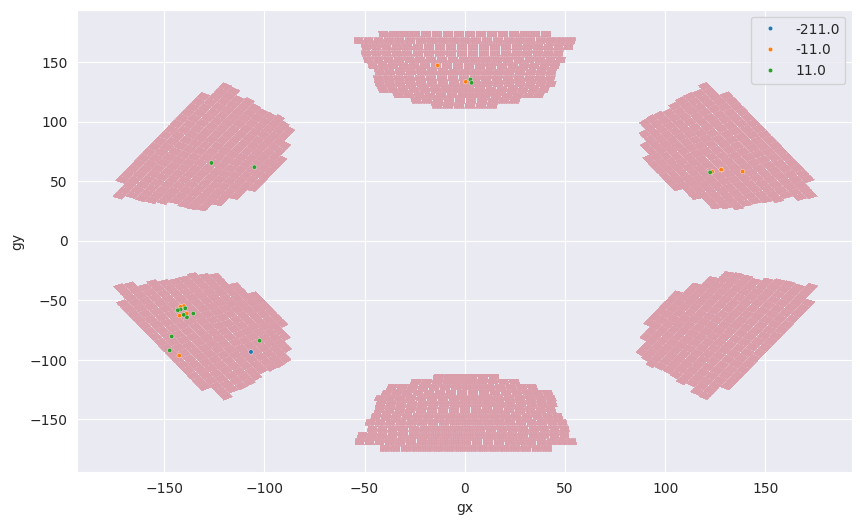

#:	11		t:	16157 ns		#hits:	9


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(


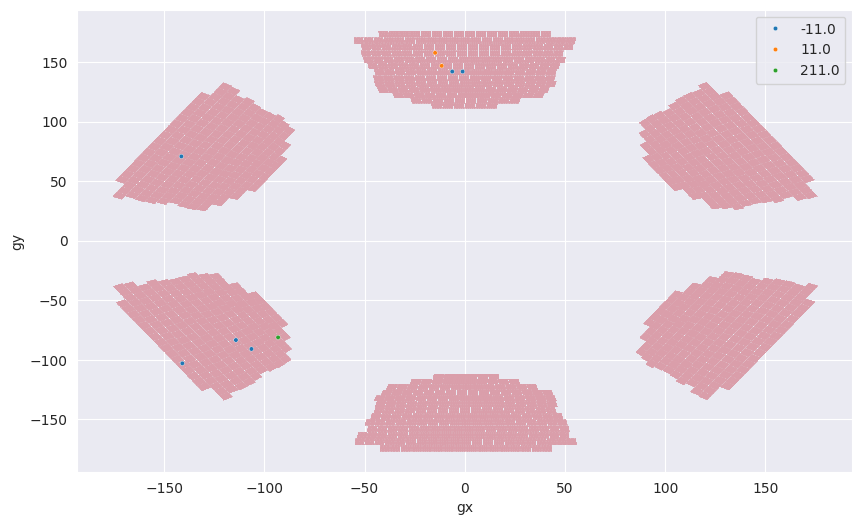

#:	12		t:	16158 ns		#hits:	3


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.scatterplot(


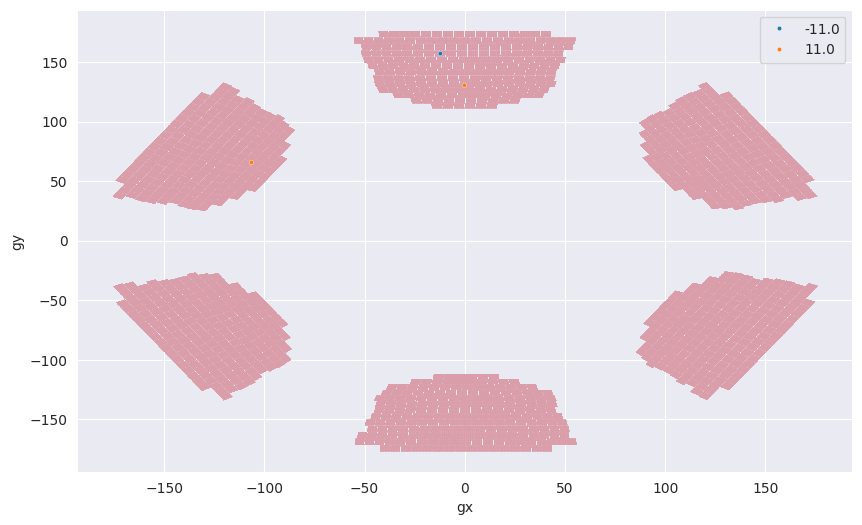

#:	13		t:	16159 ns		#hits:	1


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (1), which may not be intended.
  sns.scatterplot(


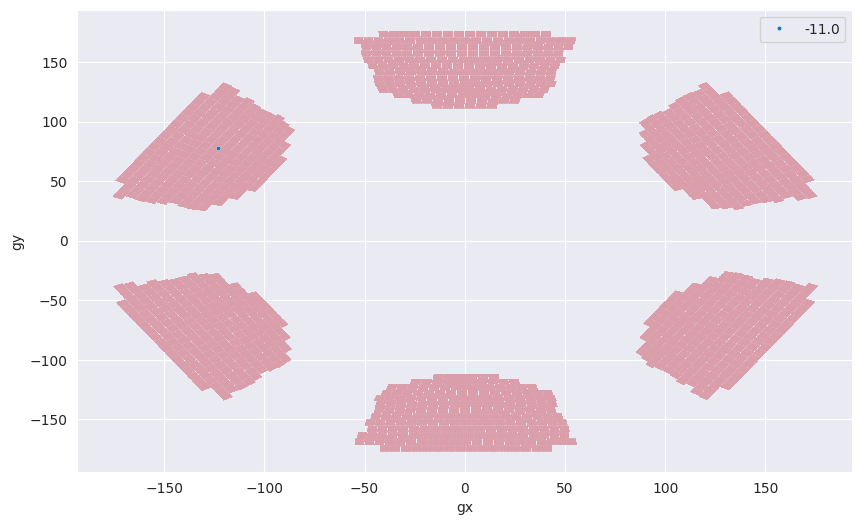

#:	14		t:	16161 ns		#hits:	3


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.scatterplot(


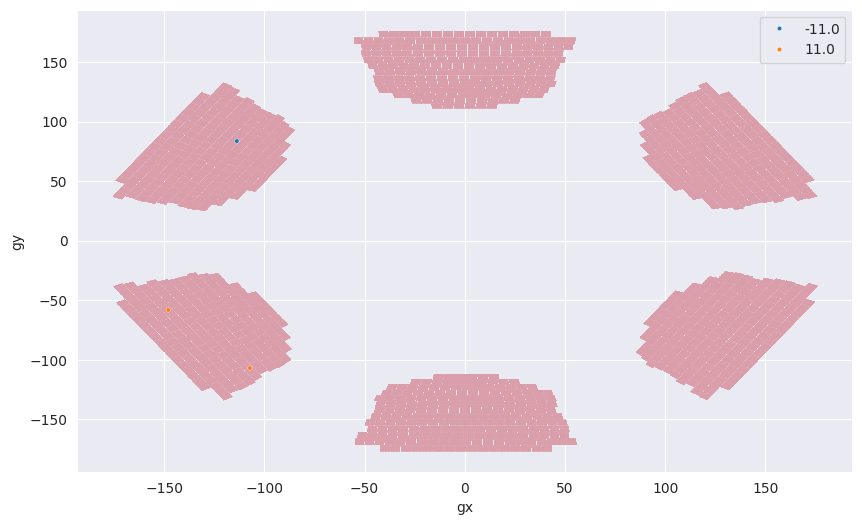

#:	15		t:	16162 ns		#hits:	3


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.scatterplot(


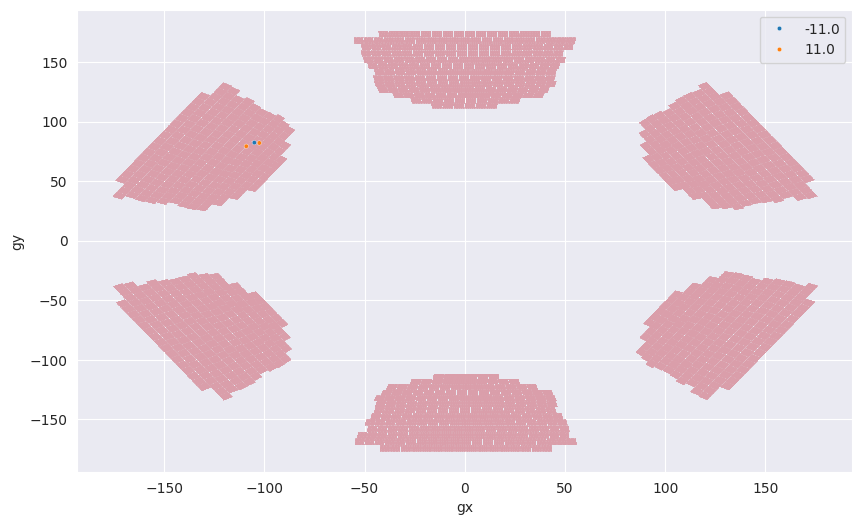

#:	16		t:	16163 ns		#hits:	3


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (1), which may not be intended.
  sns.scatterplot(


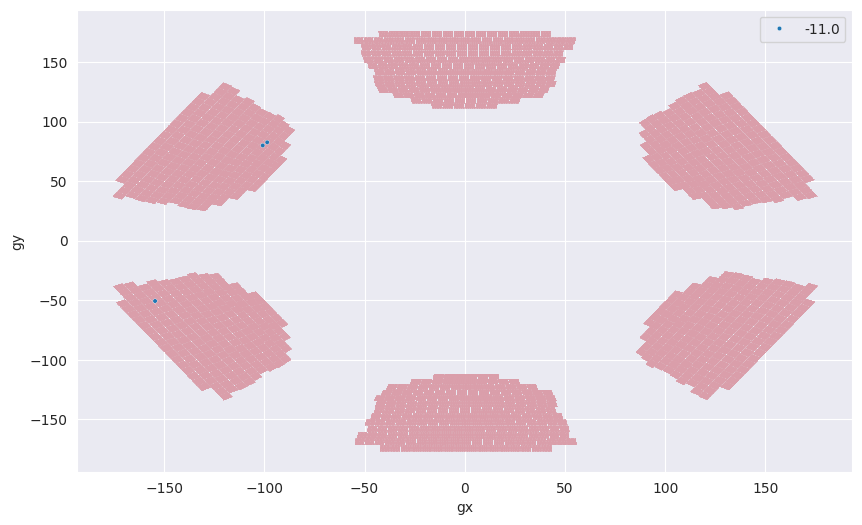

#:	17		t:	16164 ns		#hits:	5


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.scatterplot(


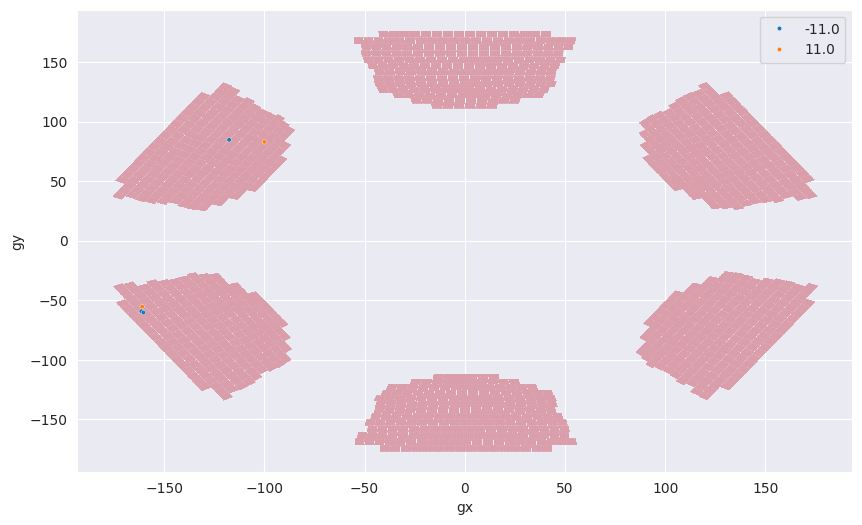

#:	18		t:	16165 ns		#hits:	2


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (1), which may not be intended.
  sns.scatterplot(


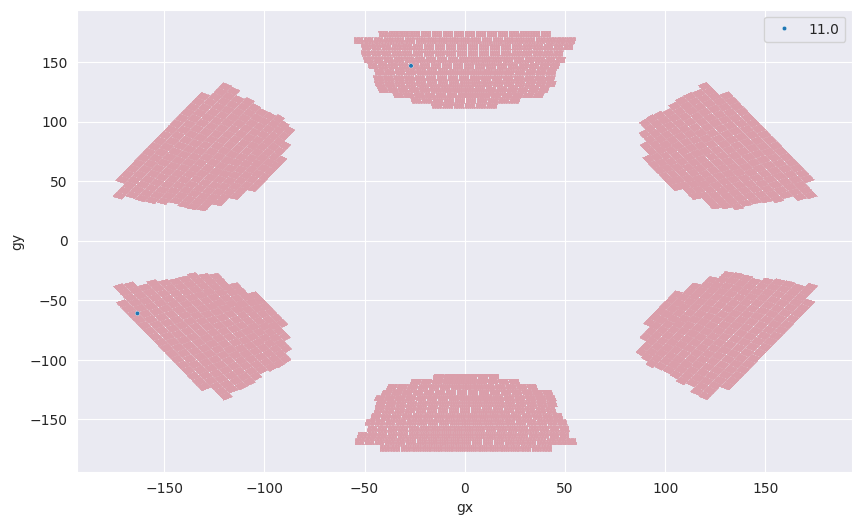

#:	19		t:	16166 ns		#hits:	1


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (1), which may not be intended.
  sns.scatterplot(


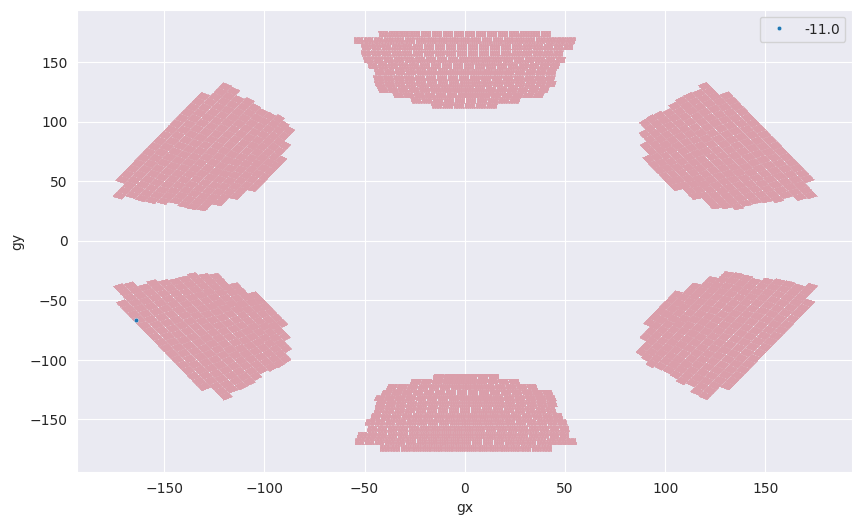

#:	20		t:	16167 ns		#hits:	1


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (1), which may not be intended.
  sns.scatterplot(


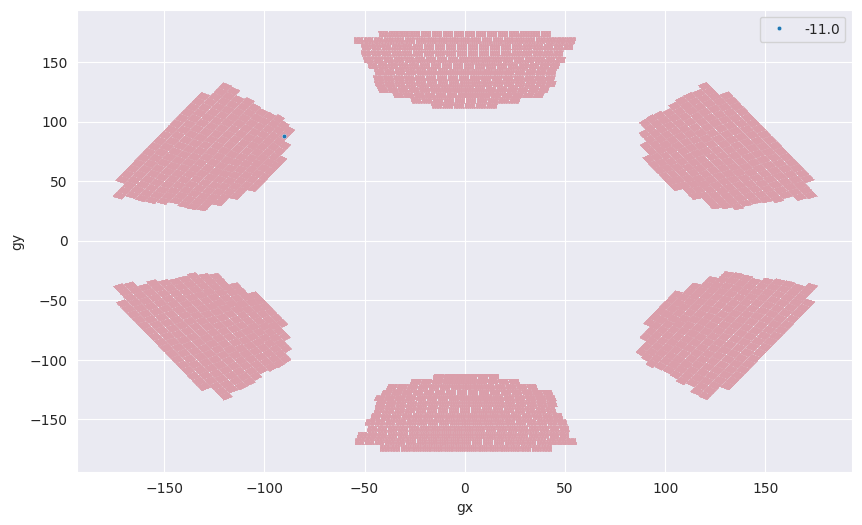

#:	21		t:	16168 ns		#hits:	1


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (1), which may not be intended.
  sns.scatterplot(


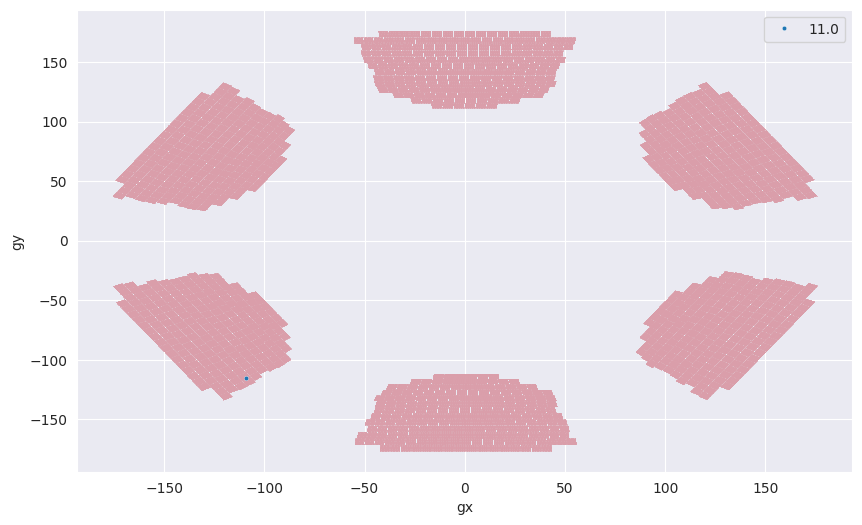

#:	22		t:	16169 ns		#hits:	1


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (1), which may not be intended.
  sns.scatterplot(


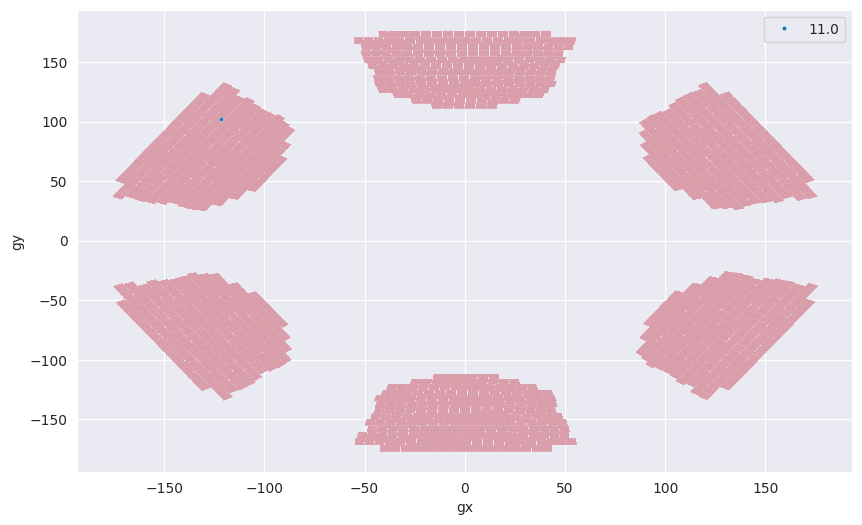

#:	23		t:	16170 ns		#hits:	1


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (1), which may not be intended.
  sns.scatterplot(


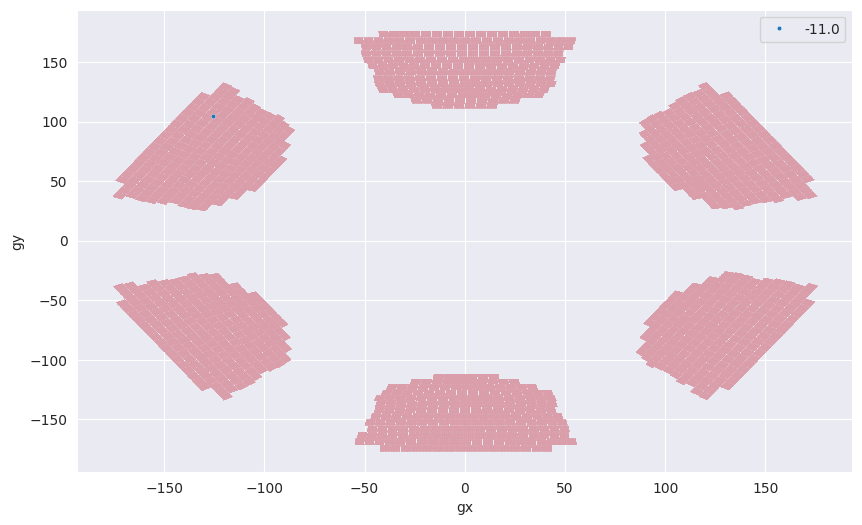

#:	24		t:	16171 ns		#hits:	1


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (1), which may not be intended.
  sns.scatterplot(


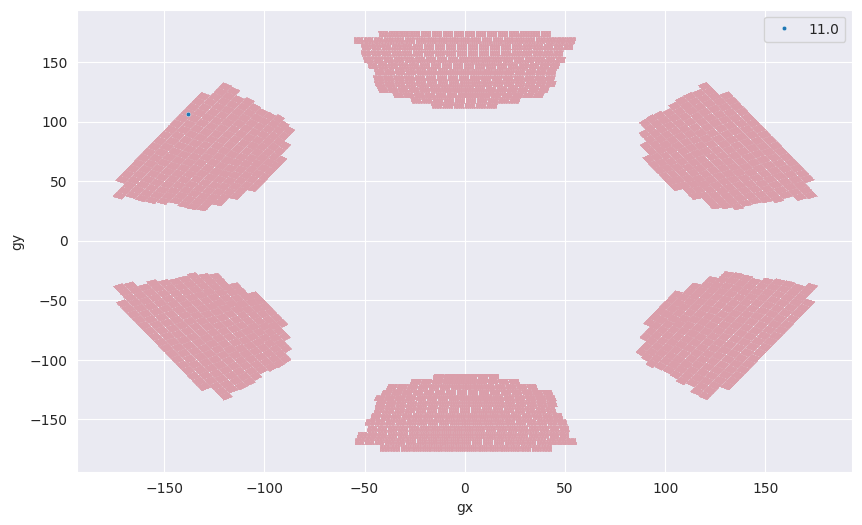

#:	25		t:	16173 ns		#hits:	1


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (1), which may not be intended.
  sns.scatterplot(


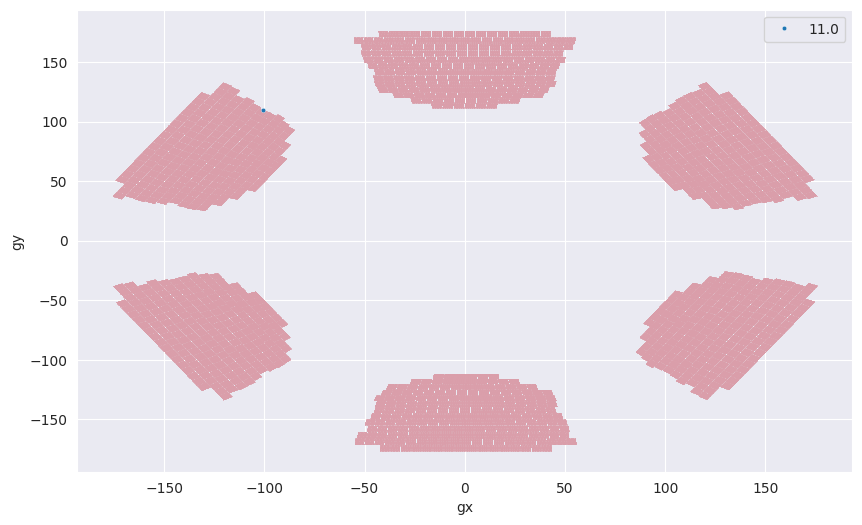

#:	26		t:	16180 ns		#hits:	1


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (1), which may not be intended.
  sns.scatterplot(


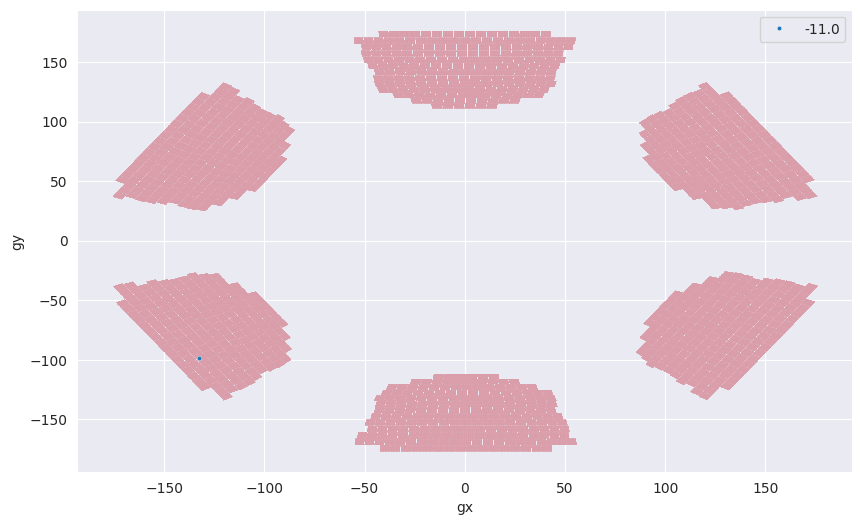

#:	27		t:	16181 ns		#hits:	1


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (1), which may not be intended.
  sns.scatterplot(


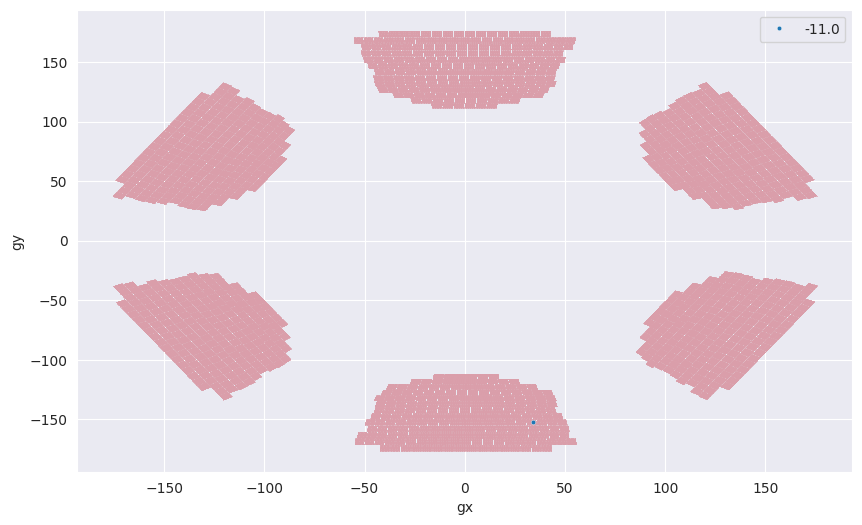

#:	28		t:	16185 ns		#hits:	1


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (1), which may not be intended.
  sns.scatterplot(


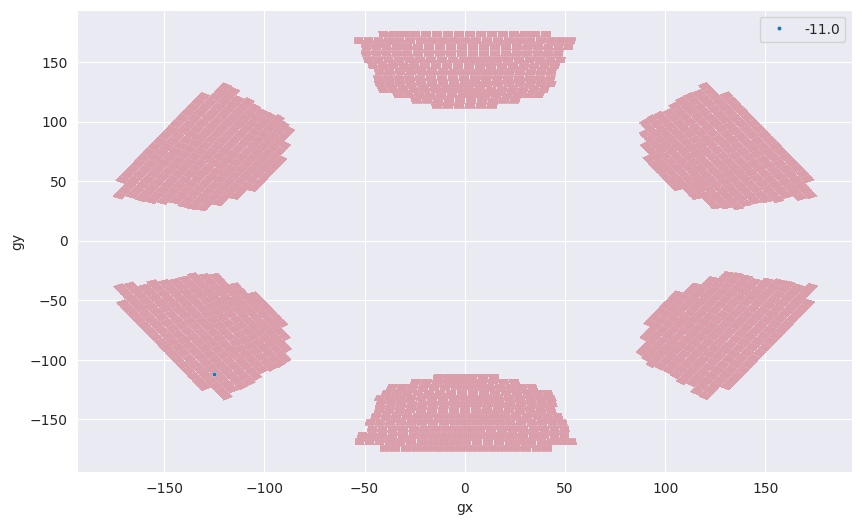

In [132]:
# Plot entire dRICH + hits from event 15 in the EIC global coordinate system.

id_event = 42
id_file = 2
id1="" if id_file>10 else "0"
id2="" if id_file>100 else "0"
id3="" if id_file>1000 else "0"
df_rec_last     = pd.read_csv(f"/content/drive/MyDrive/project_files/Bkg_new/rec_hits_{id3}{id2}{id1}{id_file}.csv", sep = ',')
df_sim_last     = pd.read_csv(f"/content/drive/MyDrive/project_files/Bkg_new/sim_parts_{id3}{id2}{id1}{id_file}.csv", sep = ',')
df_rec_show = df_rec_last
df_sim_show = df_sim_last

rf = df_rec_show[df_rec_show["event"] == id_event]
sf = df_sim_show[df_sim_show["event"] == id_event]


T,X,Y,HUE=global2d_plothits_tag_v(df_rec_show, df_sim_show, id_event)

print(f"FILE #{id_file}\nEVENT #{id_event}\nSTART\n\n")
for i in range(len(T)):
    plt.figure(figsize=(10,6))
    global2d_plotcells(df_cellmap)
    print(f"#:\t{i}\t\tt:\t{T[i]} ns\t\t#hits:\t{len(X[i])}")
    plot_(X[i],Y[i],HUE[i])
    plt.show()

In [133]:
def global2d_plothits_tag_bin(df, tf, ei):
    df = df[df["event"] == ei]
    tf = tf[tf["event"] == ei]
    massimo=max(df["time"])
    minimo=min(df["time"])
    t_tot=[]
    x_tot=[]
    y_tot=[]
    hue_tot=[]
    for t in np.linspace(minimo,massimo,5):#df["time"].unique():
        if t==massimo:
            break
        x_a=[]
        y_a=[]
        dfi = df[df["time"] >= t ]
        dfi = dfi[dfi["time"] < (t+(massimo-minimo)/4) ]
        hue_a=[]
        for idx, row in dfi.iterrows():
            x_a.append(row["gx"])
            y_a.append(row["gy"])
            if(row["pindex"]==0):
                #print("NOISE")
                hue_a.append(0)
            else:
                for idx_t, row_t in tf.iterrows():
                    if(row["pindex"]==row_t["pindex"]):
                        #print("MATCH!")
                        hue_a.append(row_t["pdg"])
                        #print(row_t["pdg"])
                        break
        t_tot.append(t)
        x_tot.append(x_a)
        y_tot.append(y_a)
        hue_tot.append(hue_a)
    #print(np.asarray(x_tot).shape)
    #print(np.asarray(y_tot).shape)
    #print(np.asarray(hue_tot).shape)
    return t_tot,x_tot,y_tot,hue_tot
    #sns.scatterplot(
    #    x = x_a, y = y_a,
    #    s = 10, hue = hue_a, palette =  sns.color_palette()
    #)


FILE #2
EVENT #42
START


#:	0		t:	14200.0 ns		#hits:	4


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.scatterplot(


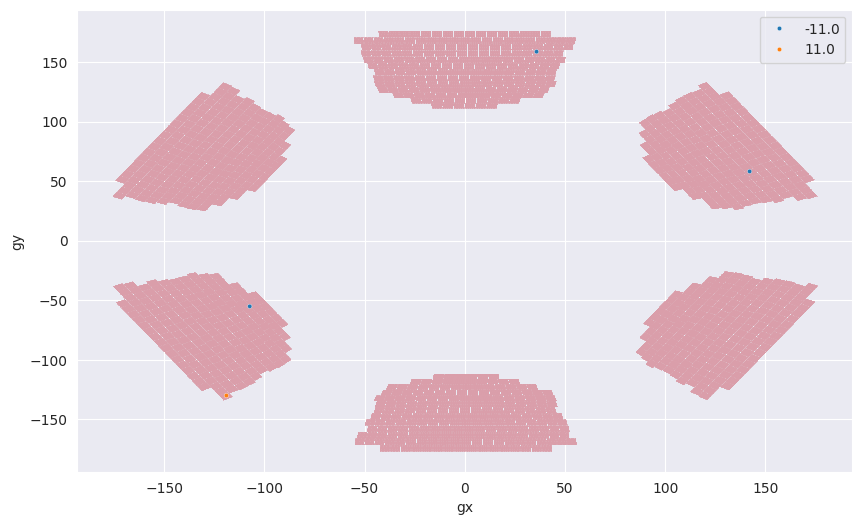

#:	1		t:	14696.25 ns		#hits:	0


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


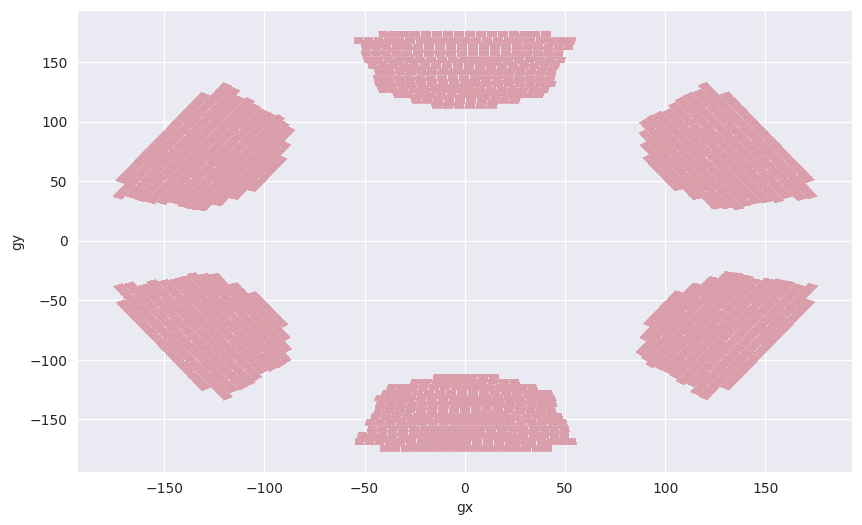

#:	2		t:	15192.5 ns		#hits:	0


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


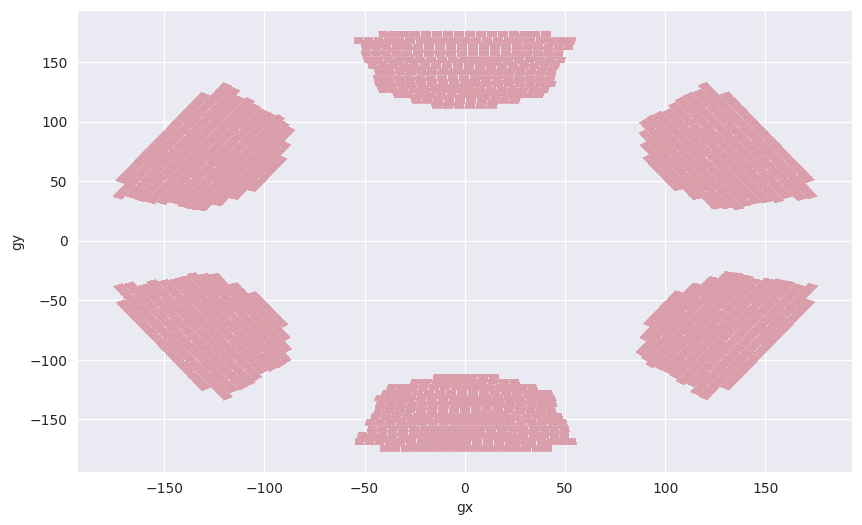

#:	3		t:	15688.75 ns		#hits:	425


/tmp/ipykernel_2920/4250670563.py:2: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(


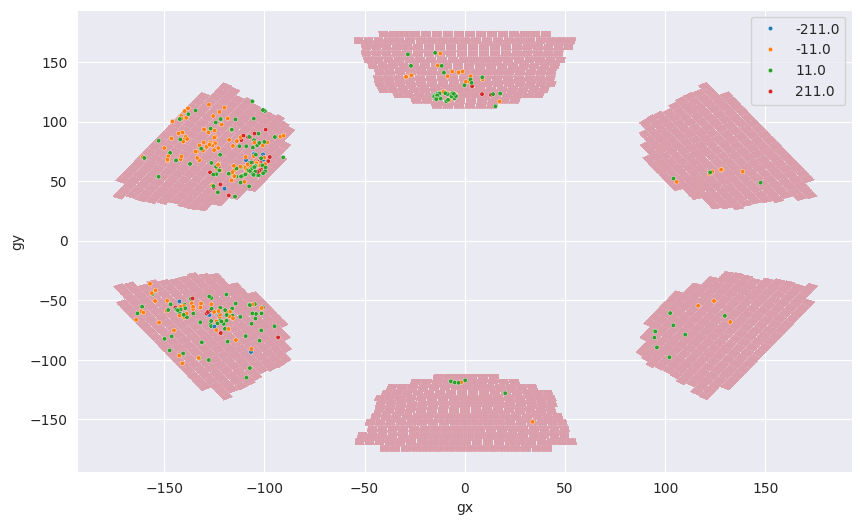

In [134]:
# Plot entire dRICH + hits from event 15 in the EIC global coordinate system.

id_event = 42
id_file = 2
id1="" if id_file>10 else "0"
id2="" if id_file>100 else "0"
id3="" if id_file>1000 else "0"
df_rec_last     = pd.read_csv(f"/content/drive/MyDrive/project_files/Bkg_new/rec_hits_{id3}{id2}{id1}{id_file}.csv", sep = ',')
df_sim_last     = pd.read_csv(f"/content/drive/MyDrive/project_files/Bkg_new/sim_parts_{id3}{id2}{id1}{id_file}.csv", sep = ',')
df_rec_show = df_rec_last
df_sim_show = df_sim_last

rf = df_rec_show[df_rec_show["event"] == id_event]
sf = df_sim_show[df_sim_show["event"] == id_event]


T,X,Y,HUE=global2d_plothits_tag_bin(df_rec_show, df_sim_show, id_event)

print(f"FILE #{id_file}\nEVENT #{id_event}\nSTART\n\n")
for i in range(len(T)):
    plt.figure(figsize=(10,6))
    global2d_plotcells(df_cellmap)
    print(f"#:\t{i}\t\tt:\t{T[i]} ns\t\t#hits:\t{len(X[i])}")
    plot_(X[i],Y[i],HUE[i])
    plt.show()

In [173]:
def build_all_dam_grids_from_csv(df_rec, df_cellmap, lookup, shapes_used,
                                  event_id, sectors=range(6), dams=range(5),
                                  verbose=True):
    """
    Reconstruit les 30 grilles 2D (une par (sec, n)) pour UN événement donné,
    directement à partir du CSV rec_hits, en passant par scatter_dam_to_grid.
    """
    # 1. Isoler l'événement
    ev = df_rec[df_rec["event"] == event_id].copy()
    n_hits_total_csv = len(ev)

    # 1bis. Sécurité : si ev contient déjà pdu/sipm/xi (héritage d'un merge
    # précédent dans le notebook), on les retire pour éviter tout conflit
    # pdu_x / pdu_y lors du merge ci-dessous.
    cols_to_drop = [c for c in ["pdu", "sipm", "xi"] if c in ev.columns]
    if cols_to_drop:
        if verbose:
            print(f"Colonnes déjà présentes dans ev, supprimées avant merge : {cols_to_drop}")
        ev = ev.drop(columns=cols_to_drop)

    # 2. Table de correspondance (sector, lx, ly) -> pdu, via le cellmap
    cellmap_lookup = df_cellmap[["sector", "lx", "ly", "pdu"]].drop_duplicates().copy()

    # 3. Cast des clés de jointure pour garantir la correspondance des types
    for col in ["sector", "lx", "ly"]:
        ev[col] = ev[col].astype(int)
        cellmap_lookup[col] = cellmap_lookup[col].astype(int)

    # 4. Merge (plus de conflit possible : ev n'a plus de colonne pdu)
    ev = ev.merge(cellmap_lookup, on=["sector", "lx", "ly"], how="left")

    if ev["pdu"].isna().any():
        n_missing = ev["pdu"].isna().sum()
        print(f"ATTENTION: {n_missing}/{len(ev)} hits sans correspondance pdu dans le cellmap")
        ev = ev.dropna(subset=["pdu"])
    ev["pdu"] = ev["pdu"].astype(int)

    # 5. subsec / subpdu, comme dans build_dam_grid_lookup_v7
    ev["subsec"] = ev["pdu"] // 42
    ev["subpdu"] = ev["pdu"] % 42

    grids, counts = {}, {}
    for sec in sectors:
        for n in dams:
            shape = shapes_used[(sec, n)]
            cell_map = lookup[(sec, n)]

            X_dam = np.zeros((1, 42))
            sub = ev[(ev["sector"] == sec) & (ev["subsec"] == n)]
            for ch, cnt in sub["subpdu"].value_counts().items():
                X_dam[0, int(ch)] = cnt

            grids[(sec, n)] = scatter_dam_to_grid(X_dam, cell_map, shape)
            counts[(sec, n)] = X_dam.sum()

    n_hits_total_dam = sum(counts.values())
    if verbose:
        print(f"Hits dans le CSV (event {event_id})         : {n_hits_total_csv}")
        print(f"Hits reconstruits via les grilles DAM        : {n_hits_total_dam}")
        print("=> Cohérent" if n_hits_total_csv == n_hits_total_dam else "=> INCOHÉRENT, vérifier le merge")

    return grids, counts, ev

In [174]:
print(type(ev))

event_id = 42

ev_test = df_rec_last[df_rec_last["event"] == event_id].copy()
cellmap_lookup = df_cellmap[["sector", "lx", "ly", "pdu"]].drop_duplicates()

for col in ["sector", "lx", "ly"]:
    ev_test[col] = ev_test[col].astype(int)
    cellmap_lookup[col] = cellmap_lookup[col].astype(int)

test = ev_test.merge(cellmap_lookup, on=["sector", "lx", "ly"], how="left")
print(test["pdu_y"].isna().mean())

<class 'pandas.core.frame.DataFrame'>
0.0


In [175]:
test = df_rec_last[["sector","lx","ly"]].drop_duplicates().merge(
    df_cellmap[["sector","lx","ly","pdu"]].drop_duplicates(),
    on=["sector","lx","ly"], how="left"
)
print(test["pdu"].isna().mean())  # proportion de non-matchs



0.0


In [177]:
grids, counts, ev_merged = build_all_dam_grids_from_csv(
    df_rec_last, df_cellmap, lookup, shapes_used, event_id=42
)

Colonnes déjà présentes dans ev, supprimées avant merge : ['pdu', 'sipm', 'xi']
Hits dans le CSV (event 42)         : 430
Hits reconstruits via les grilles DAM        : 430.0
=> Cohérent


In [178]:
hits_csv_par_secteur = df_rec_last[df_rec_last["event"]==42].groupby("sector").size()
hits_dam_par_secteur = {sec: sum(counts[(sec,n)] for n in range(5)) for sec in range(6)}
print(hits_csv_par_secteur)
print(hits_dam_par_secteur)

sector
0     10
1     71
2    208
3    122
4      7
5     12
dtype: int64
{0: np.float64(10.0), 1: np.float64(71.0), 2: np.float64(208.0), 3: np.float64(122.0), 4: np.float64(7.0), 5: np.float64(12.0)}


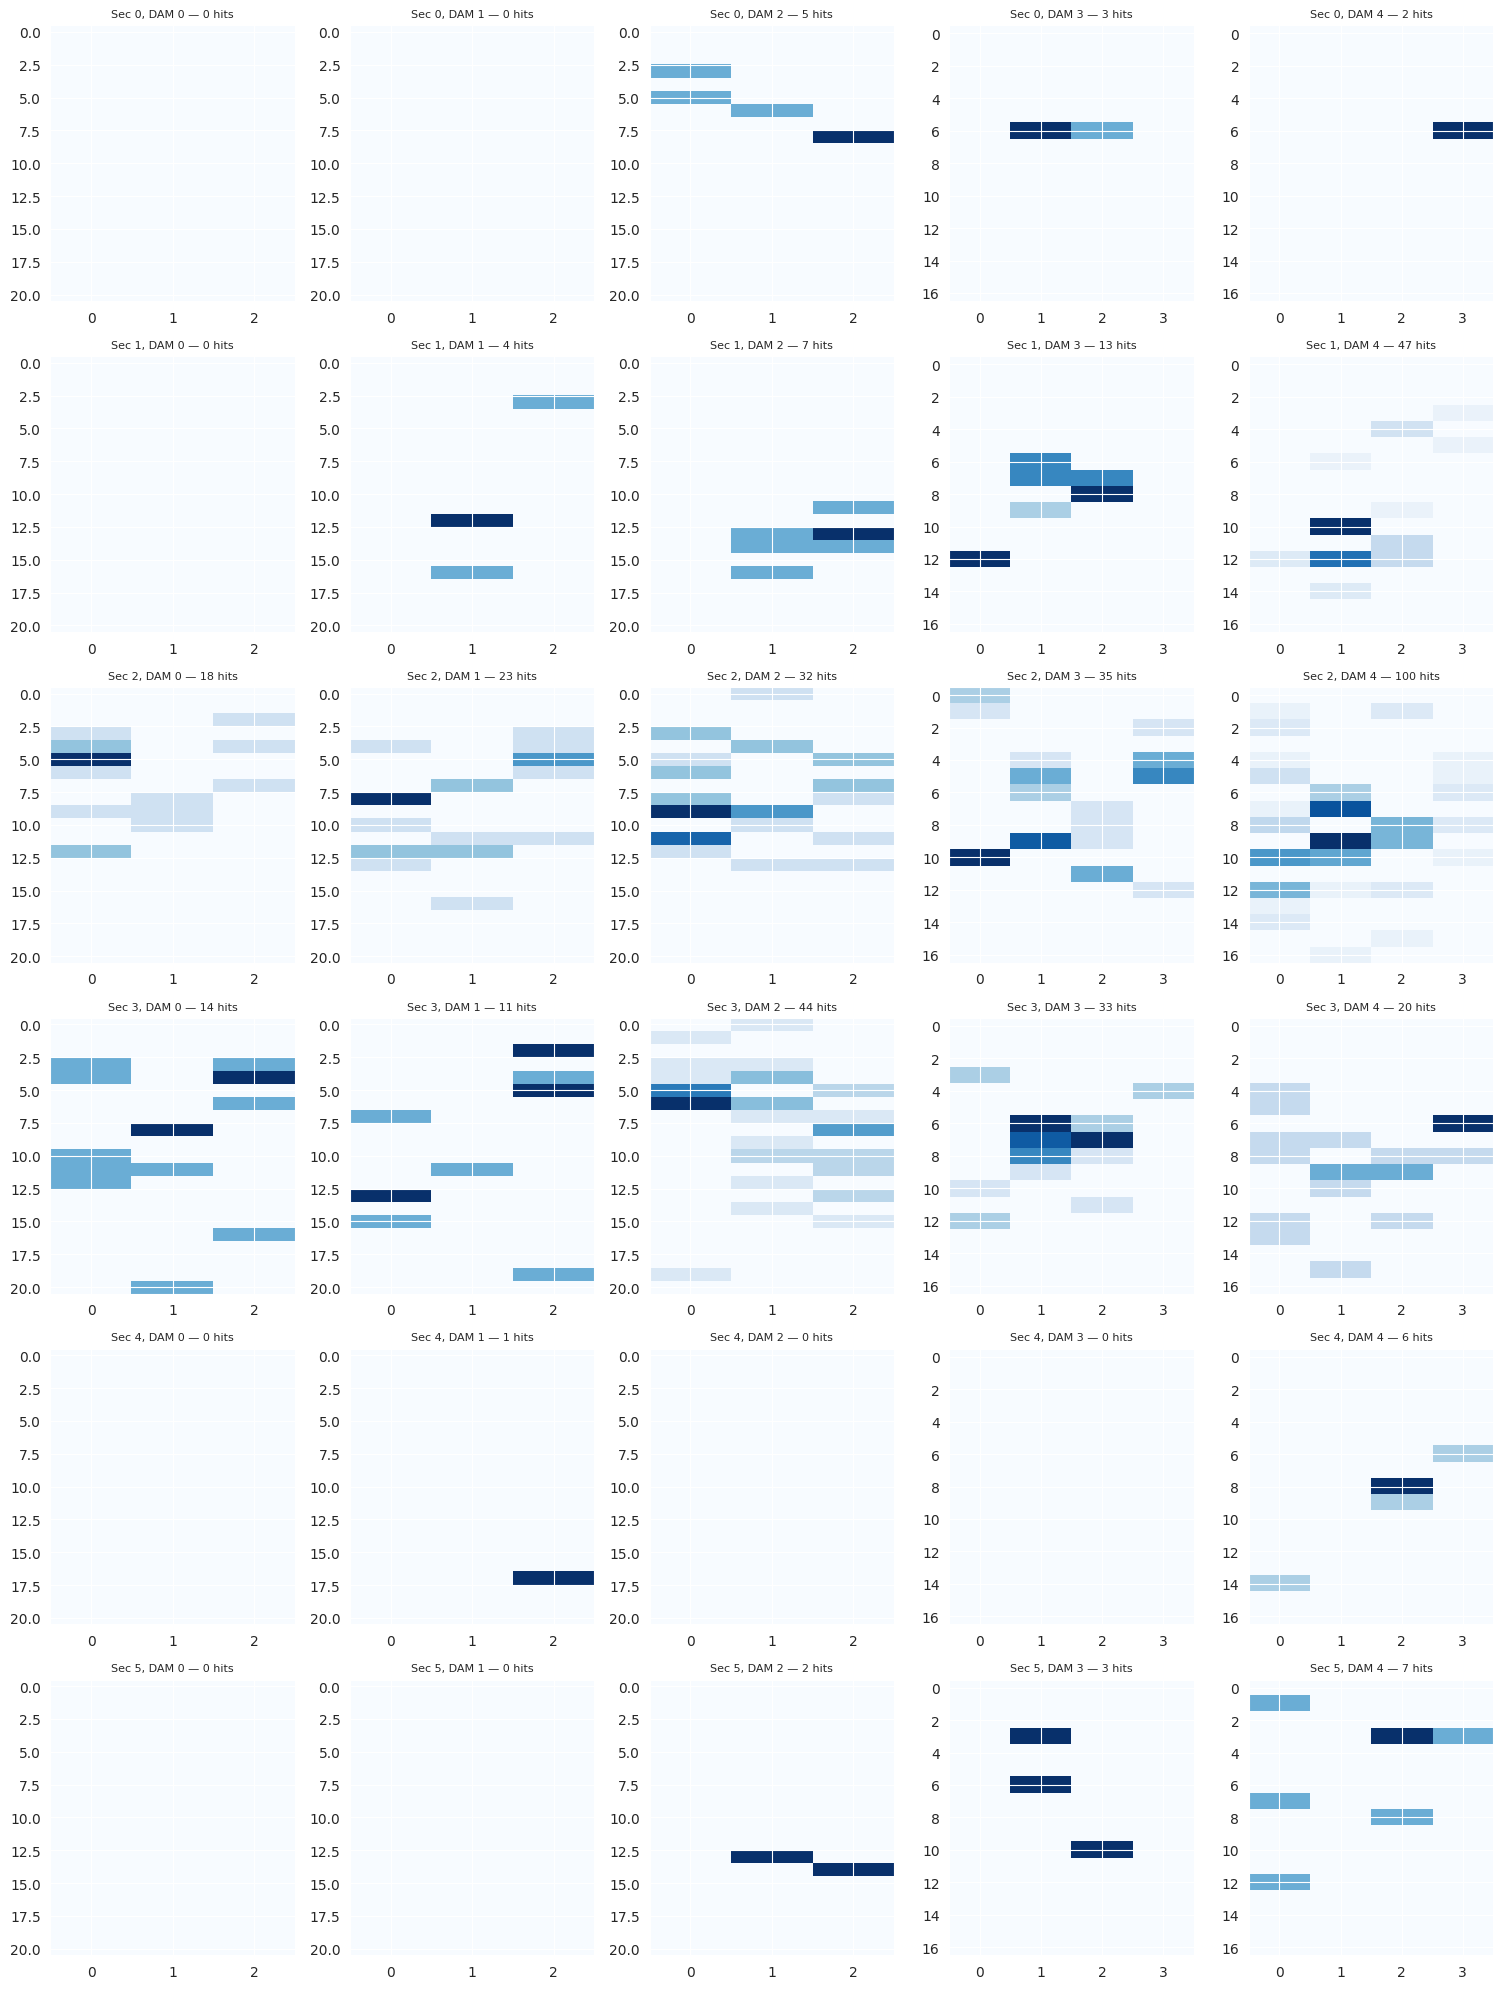

START
(430,)
(430,)
(430,)


/tmp/ipykernel_2920/2336447550.py:45: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(


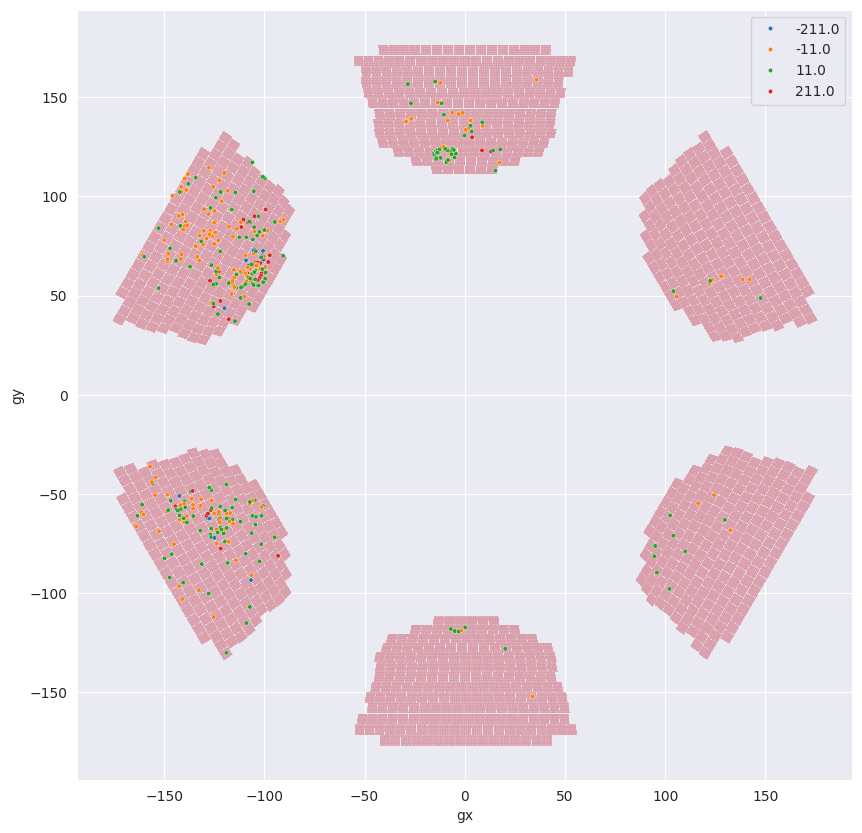

In [179]:
fig, axes = plt.subplots(6, 5, figsize=(15, 20))
for sec in range(6):
    for n in range(5):
        ax = axes[sec, n]
        ax.imshow(grids[(sec, n)][0, :, :, 0], cmap="Blues", aspect="auto")
        ax.set_title(f"Sec {sec}, DAM {n} — {int(counts[(sec,n)])} hits", fontsize=8)
plt.tight_layout()
plt.show()

# à comparer visuellement avec :
plt.figure(figsize=(10, 10))
global2d_plotcells(df_cellmap)
global2d_plothits_tag(df_rec_last, df_sim_last, 42)
plt.show()

In [180]:
import numpy as np

centroids = df_cellmap.groupby("sector")[["gx", "gy"]].mean()
centroids["angle_deg"] = np.degrees(np.arctan2(centroids["gy"], centroids["gx"])) % 360
print(centroids.sort_values("angle_deg"))

                gx          gy   angle_deg
sector                                    
0       126.575935   73.337805   30.087904
1        -0.224435  146.286878   90.087904
2      -126.800370   72.949073  150.087904
3      -126.575935  -73.337805  210.087904
4         0.224435 -146.286878  270.087904
5       126.800370  -72.949073  330.087904
